# 01. SCADA·예보 데이터 탐색 (data nogada)

`TRAIN/` 폴더의 SCADA(터빈 실측)와 예보(LDAPS/GFS) 데이터를 훑어 모델링 입력 후보를 정한다.

| Step | 내용 |
|---|---|
| 1 | 파일 경로 확인 및 원본 로드 |
| 2 | 터빈 메타 정보 구성 (그룹·정격) |
| 3 | 바람 벡터·물리 계산 클래스 정의 |
| 4 | SCADA 10분 → KPX 그룹 시간별 집계 |
| 5 | 발전량 추이 확인 (월별·연도별) |
| 6 | 풍속·풍향과 발전량의 관계 분석 |
| 7 | 예보(LDAPS/GFS) 대표값 계산 및 실측 비교 |
| 8 | 예보 U/V 편차·계절성 비교 |
| 9 | 탐색 결과 정리 |

**확인하려는 것**

1. 터빈 데이터를 KPX 그룹(1, 2, 3) 단위로 합치면 공식 라벨과 맞는가
2. 월별·연도별 발전량에 반복되는 계절 패턴이 있는가
3. "풍속이 셀수록 발전량이 느는가"를 숫자(상관계수)로 확인
4. 평가 기간에 실제로 쓸 수 있는 **예보 데이터만으로** 발전량을 설명할 수 있는가

## Step 0. 라이브러리와 상수

임계값·설비용량처럼 나중에 바꿔가며 실험할 값은 코드 중간에 흘리지 않고 여기 한 곳에 모은다.

In [87]:
# Step 0. 라이브러리

from pathlib import Path
from typing import Dict, List, Tuple
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [88]:
# --- 경로 ---
PROJECT_ROOT = Path(".")
# 노트북을 저장소 루트에서 실행하는 것을 전제로 한다 (다른 위치면 이 한 줄만 바꾼다)

# --- KPX 그룹 (INFO/info.xlsx의 그룹설비용량(MW)을 kWh로 환산) ---
GROUPS = ["kpx_group_1", "kpx_group_2", "kpx_group_3"]
# 그룹 순서를 고정해두고 표·그래프에서 계속 재사용한다
GROUP_CAP_KWH = {
    "kpx_group_1": 21_600.0,
    # VESTAS V126 3.6MW x 6기 = 21.6MW = 21,600kWh (1시간 기준)
    "kpx_group_2": 21_600.0,
    # VESTAS V126 3.6MW x 6기 = 21.6MW = 21,600kWh
    "kpx_group_3": 21_000.0,
    # UNISON U136 4.2MW x 5기 = 21.0MW = 21,000kWh
}

# --- SCADA 품질 기준 ---
POWER_CAP_RATIO = 1.05
# 터빈 정격의 105%를 넘는 10분 발전량은 센서 오류로 본다
SAMPLES_PER_HOUR = 6
# 10분 간격이므로 1시간에 10분값이 6개 들어간다

# --- 분석 기준 ---
CUT_IN_MS = 3.0
# 컷인 풍속. V126·U136 둘 다 3 m/s이며 이보다 낮으면 발전을 안 하므로 효율 분석에서 제외한다
DIRECTION_SECTOR_DEG = 45
# 360/45 = 8방위로 묶어 방위별 효율을 본다
ANALYSIS_END = "2025-01-01"
# 2025-01-01 00:00 한 시각만 다음 달로 끼어드는 경계값이라 월별 집계에서 제외한다
SEASON_YEARS = [2022, 2023, 2024]
# 연도별 주간 발전량을 겹쳐 그릴 때 쓸 시작 연도

# --- 공기밀도 상수 (MD/04. 전처리 방법론 고민 참고) ---
R_D = 287.05
# 건조공기 기체상수 J/(kg·K)
EPSILON = 0.62197
# 건조공기/수증기 기체상수 비(Rd/Rv). 수증기압 식의 분모에 들어간다
ONE_MINUS_EPS = 0.37803
# 1 - EPSILON

# --- 계절 구분 (Step 8 비교용) ---
SEASON_MONTH = {
    6: "하절기", 7: "하절기", 8: "하절기",
    12: "동절기", 1: "동절기", 2: "동절기",
}
# 봄·가을(환절기)은 성질이 섞여 있어 이번 계절 비교에서 제외한다

# --- 그래프 설정 ---
plt.rcParams["font.family"] = "Malgun Gothic"
# 한글 라벨이 네모로 깨지지 않도록 Windows 기본 한글 폰트를 지정
plt.rcParams["axes.unicode_minus"] = False
# 마이너스(-) 기호가 깨지는 것을 방지
pd.set_option("display.max_columns", 50)
# 표를 볼 때 컬럼이 생략되지 않게 넉넉히 잡는다

## Step 1. 파일 경로 확인 및 원본 로드

15만 행짜리 CSV를 읽다가 마지막에 파일이 없다고 죽는 것을 막기 위해, 로딩 전에 경로부터 한 번에 확인한다.

In [89]:
@dataclass
class WindforceDataLoader:
    """WINDFORCE 원본 데이터 로드를 담당하는 클래스

    Attributes:
        - _paths : 파일명 -> 실제 경로 레지스트리
        - _cache : 파일명 -> 로딩된 DataFrame 캐시
        - 경로 확인(_paths)과 데이터 로딩(_cache)을 분리해두면
          파일이 있는지만 먼저 확인하고 무거운 로딩은 나중에 할 수 있다
    """

    root: Path = PROJECT_ROOT
    # 저장소 루트 경로 (기본값)
    encoding: str = "utf-8-sig"
    # 명세서상 원본 CSV가 BOM 있는 UTF-8로 저장되어 있어 인코딩을 명시한다

    root_train: Path = field(init=False)
    # __post_init__에서 채워짐 (생성자 인자로 받지 않음)
    root_info: Path = field(init=False)
    # __post_init__에서 채워짐
    _paths: Dict[str, Path] = field(default_factory=dict, init=False)
    # 파일명 -> 경로 매핑, 초기값은 빈 딕셔너리
    _cache: Dict[str, pd.DataFrame] = field(default_factory=dict, init=False)
    # 파일명 -> 로딩된 DataFrame 캐시, 초기값은 빈 딕셔너리

    def __post_init__(self):
        """dataclass의 __init__ 실행 직후 자동 호출되는 메서드"""
        self.root_train = self.root / "TRAIN"
        self.root_info = self.root / "INFO"

        self._paths = {
            "scada_vestas_train": self.root_train / "scada_vestas_train.csv",
            # VESTAS 12기 터빈 단위 10분 실측 (157,819행, 2022-01-01 01:00 ~ 2025-01-01 00:00)
            "scada_unison_train": self.root_train / "scada_unison_train.csv",
            # UNISON 5기 터빈 단위 10분 실측 (105,264행, 2023-01-01 00:10 시작)
            "ldaps_train": self.root_train / "ldaps_train.csv",
            # LDAPS 예보. 약 1.5km 공간해상도의 16개 격자 x 매시간 (420,864행)
            "gfs_train": self.root_train / "gfs_train.csv",
            # GFS 예보. 약 0.25도 공간해상도의 9개 격자 x 매시간
            "train_labels": self.root_train / "train_labels.csv",
            # KPX 그룹별 시간당 실제 발전량 (정답값)
            "turbine_info": self.root_info / "info.xlsx",
            # 터빈 17기의 그룹·좌표·정격 정보. 유일한 엑셀 파일이다
        }

    def checkPath(self) -> Dict[str, bool]:
        """등록된 모든 경로의 존재 여부를 확인하는 메서드"""
        status = {}
        for name, path in self._paths.items():
            exists = path.exists()
            # 해당 경로에 실제 파일이 있는지 확인
            status[name] = exists
            mark = "O" if exists else "X"
            print(f"{mark}  {name}: {path}")
        return status
        # 파일명 -> 존재 여부 딕셔너리 반환

    def load(self, name: str, force: bool = False, **kwargs) -> pd.DataFrame:
        """개별 파일을 로드하는 메서드 (캐싱 지원)

        Args:
            - name  : _paths에 등록된 파일명
            - force : True면 캐시를 무시하고 다시 읽는다

        Logic:
            - LDAPS는 42만 행이라 재로딩 비용이 커서 한 번 읽은 파일은 캐시에서 꺼낸다
            - info.xlsx만 엑셀이라 읽는 함수를 확장자로 분기한다
        """
        if name not in self._paths:
            raise KeyError(f"'{name}'은 등록된 파일이 아닙니다. 사용 가능: {list(self._paths.keys())}")
        if name in self._cache and not force:
            return self._cache[name]
            # 이미 캐시에 있으면 바로 반환 (재로딩 방지)

        path = self._paths[name]
        if path.suffix == ".xlsx":
            df = pd.read_excel(path, **kwargs)
        else:
            df = pd.read_csv(path, encoding=self.encoding, **kwargs)
        self._cache[name] = df
        return df
        # 로딩한 DataFrame 반환

    def loadAll(self, force: bool = False) -> Dict[str, pd.DataFrame]:
        """등록된 전체 파일을 로드하는 메서드"""
        for name in self._paths:
            try:
                self.load(name, force=force)
                print(f"O {name}: shape={self._cache[name].shape}")
            except Exception as e:
                print(f"X {name}: {e}")
                # 개별 파일 실패가 전체 로딩을 중단시키지 않도록 예외를 여기서 잡는다
        return self._cache

    def summarize(self, name: str) -> None:
        """컬럼 수와 날짜 범위를 요약 출력하는 메서드"""
        df = self.load(name)
        print(f"[{name}] {df.shape[0]:,}행 x {df.shape[1]}열")
        date_cols = [c for c in df.columns if any(k in c.lower() for k in ["dtm", "date", "time"])]
        # 컬럼명에 시간 관련 키워드가 들어간 컬럼만 추린다
        for date_col in date_cols:
            try:
                parsed = pd.to_datetime(df[date_col])
                print(f"  {date_col}: {parsed.min()} ~ {parsed.max()}")
            except Exception:
                print(f"  {date_col}: 파싱 실패 (샘플: {df[date_col].iloc[0]})")

    def __getitem__(self, name: str) -> pd.DataFrame:
        return self.load(name)
        # loader["scada_vestas_train"] 형태의 딕셔너리 접근을 지원한다

In [90]:
loader = WindforceDataLoader()
# 클래스 인스턴스 생성 (root 기본값 사용)
loader.checkPath()
# 무거운 로딩 전에 경로 존재 여부부터 확인

O  scada_vestas_train: TRAIN\scada_vestas_train.csv
O  scada_unison_train: TRAIN\scada_unison_train.csv
O  ldaps_train: TRAIN\ldaps_train.csv
O  gfs_train: TRAIN\gfs_train.csv
O  train_labels: TRAIN\train_labels.csv
O  turbine_info: INFO\info.xlsx


{'scada_vestas_train': True,
 'scada_unison_train': True,
 'ldaps_train': True,
 'gfs_train': True,
 'train_labels': True,
 'turbine_info': True}

In [91]:
# 시간 컬럼을 문자열에서 진짜 날짜/시간 타입으로 바꿔둔다 (뒤의 모든 시간 연산이 이걸 전제로 한다)
vestas = loader["scada_vestas_train"].copy()
vestas["kst_dtm"] = pd.to_datetime(vestas["kst_dtm"])
unison = loader["scada_unison_train"].copy()
unison["kst_dtm"] = pd.to_datetime(unison["kst_dtm"])

loader.summarize("scada_vestas_train")
loader.summarize("scada_unison_train")
print()
print("VESTAS:", vestas.shape, "| UNISON:", unison.shape)
print("풍속(_ws)이 가장 중요한 독립변수이고, 풍향(_wd)은 요 편차·후류 손실 분석에 쓴다")

[scada_vestas_train] 157,819행 x 37열
  kst_dtm: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00
[scada_unison_train] 105,264행 x 16열
  kst_dtm: 2023-01-01 00:10:00 ~ 2025-01-01 00:00:00

VESTAS: (157819, 37) | UNISON: (105264, 16)
풍속(_ws)이 가장 중요한 독립변수이고, 풍향(_wd)은 요 편차·후류 손실 분석에 쓴다


## Step 2. 터빈 메타 정보 구성

발전량 라벨(`train_labels.csv`)은 터빈 단위가 아니라 **KPX 그룹(1, 2, 3) 단위**다.
어떤 터빈이 어느 그룹인지는 `INFO/info.xlsx`에 적혀 있으므로 이 파일을 읽어 매핑을 만든다.

주의: `info.xlsx`는 3번째 줄부터 진짜 표가 시작되고(`header=2`), 맨 앞에 빈 열이 하나 있으며,
`KPX그룹` 컬럼이 병합 셀이라 그대로 읽으면 중간이 비어 있다.

In [92]:
class TurbineMetaLoader:
    """터빈 17기의 그룹·정격 메타 정보 구성을 담당하는 클래스

    Attributes:
        - 그룹1 : VESTAS V126 1~6호기
        - 그룹2 : VESTAS V126 7~12호기
        - 그룹3 : UNISON U136 1~5호기
    """

    def __init__(self, loader: WindforceDataLoader):
        self.loader = loader
        # 엑셀 로딩은 WindforceDataLoader에 맡기고 이 클래스는 표 정리만 담당한다

    def loadRawInfo(self) -> pd.DataFrame:
        """info.xlsx의 헤더·병합셀을 정리해 평평한 표로 만드는 메서드"""
        info = self.loader.load("turbine_info", header=2)
        # 3번째 줄부터 진짜 표가 시작된다
        info = info.iloc[:, 1:]
        # 맨 앞의 빈 열 하나를 제거
        info.columns = info.iloc[0]
        # 첫 번째 줄 내용을 실제 컬럼 이름으로 사용
        info = info.iloc[1:].reset_index(drop=True)
        # 컬럼 이름으로 쓴 첫 줄은 지우고 인덱스 재설정
        info["KPX그룹"] = info["KPX그룹"].ffill().astype(int)
        # 병합 셀이라 비어 있던 그룹 번호를 바로 위 값으로 채운다
        return info

    def computeTurbineName(self, maker: str, unit: int) -> str:
        """제작사·호기로 SCADA 컬럼 접두사와 같은 터빈 이름을 만드는 메서드

        Logic:
            - ("VESTAS", 1) -> "vestas_wtg01"
            - SCADA 컬럼 vestas_wtg01_power_kw10m 과 접두사가 같아야 뒤에서 f-string으로 조립할 수 있다
        """
        return f"{maker.lower()}_wtg{unit:02d}"

    def transformTurbineMeta(self) -> pd.DataFrame:
        """터빈 1기 = 1행인 메타 표를 만드는 메서드

        Logic:
            - 설비용량(MW) x 1000 = kW
            - kW / 6 = 10분(1시간의 1/6) 동안 낼 수 있는 최대 발전량(kWh)
            - 10분 정격은 Step 4에서 이상치(정격 105% 초과) 판단 기준으로 재사용된다
        """
        info = self.loadRawInfo()

        meta_rows = []
        # 터빈 한 기당 한 줄씩 담을 리스트
        for _, row in info.iterrows():
            maker = str(row["제작사"])
            meta_rows.append({
                "turbine": self.computeTurbineName(maker, int(row["호기"])),
                "maker": maker,
                "model": str(row["모델명"]),
                "group": f"kpx_group_{row['KPX그룹']}",
                # 라벨 컬럼명(kpx_group_1)과 같은 형식으로 맞춘다
                "hub_height_m": float(row["Hub Height(m)"]),
                "rotor_diameter_m": float(row["Rotor Diameter(m)"]),
                "capacity_mw": float(row["설비용량(MW)"]),
            })

        meta = pd.DataFrame(meta_rows)
        meta["cap_kw"] = meta["capacity_mw"] * 1000
        # MW -> kW
        meta["cap_kwh10m"] = meta["cap_kw"] / SAMPLES_PER_HOUR
        # 10분 기준 최대 발전량(kWh)
        return meta

    def computeGroupMap(self, meta: pd.DataFrame, maker: str) -> Dict[str, str]:
        """특정 제작사 터빈만 골라 '터빈명 -> 그룹명' 딕셔너리를 만드는 메서드

        Args:
            - meta  : transformTurbineMeta()의 결과
            - maker : "VESTAS" 또는 "UNISON"
        """
        part = meta.loc[meta["maker"] == maker]
        return dict(zip(part["turbine"], part["group"]))

    def computeCapacityMap(self, meta: pd.DataFrame) -> Dict[str, float]:
        """'터빈명 -> 10분 정격 발전량(kWh)' 딕셔너리를 만드는 메서드"""
        return dict(zip(meta["turbine"], meta["cap_kwh10m"]))

In [93]:
meta_loader = TurbineMetaLoader(loader)
turbine_meta = meta_loader.transformTurbineMeta()
# 터빈 17기 메타 표 생성

vestas_group = meta_loader.computeGroupMap(turbine_meta, "VESTAS")
unison_group = meta_loader.computeGroupMap(turbine_meta, "UNISON")
turbine_cap_kwh10m = meta_loader.computeCapacityMap(turbine_meta)
# 뒤에서 계속 재사용할 매핑들을 미리 꺼내둔다

print("VESTAS 터빈 -> 그룹:", vestas_group)
print("UNISON 터빈 -> 그룹:", unison_group)
print("그룹별 터빈 수:", turbine_meta["group"].value_counts().sort_index().to_dict())
turbine_meta

VESTAS 터빈 -> 그룹: {'vestas_wtg01': 'kpx_group_1', 'vestas_wtg02': 'kpx_group_1', 'vestas_wtg03': 'kpx_group_1', 'vestas_wtg04': 'kpx_group_1', 'vestas_wtg05': 'kpx_group_1', 'vestas_wtg06': 'kpx_group_1', 'vestas_wtg07': 'kpx_group_2', 'vestas_wtg08': 'kpx_group_2', 'vestas_wtg09': 'kpx_group_2', 'vestas_wtg10': 'kpx_group_2', 'vestas_wtg11': 'kpx_group_2', 'vestas_wtg12': 'kpx_group_2'}
UNISON 터빈 -> 그룹: {'unison_wtg01': 'kpx_group_3', 'unison_wtg02': 'kpx_group_3', 'unison_wtg03': 'kpx_group_3', 'unison_wtg04': 'kpx_group_3', 'unison_wtg05': 'kpx_group_3'}
그룹별 터빈 수: {'kpx_group_1': 6, 'kpx_group_2': 6, 'kpx_group_3': 5}


,turbine,maker,model,group,hub_height_m,rotor_diameter_m,capacity_mw,cap_kw,cap_kwh10m
0,vestas_wtg01,VESTAS,V126,kpx_group_1,117.0,126.0,3.6,3600.0,600.0
1,vestas_wtg02,VESTAS,V126,kpx_group_1,117.0,126.0,3.6,3600.0,600.0
2,vestas_wtg03,VESTAS,V126,kpx_group_1,117.0,126.0,3.6,3600.0,600.0
3,vestas_wtg04,VESTAS,V126,kpx_group_1,117.0,126.0,3.6,3600.0,600.0
4,vestas_wtg05,VESTAS,V126,kpx_group_1,117.0,126.0,3.6,3600.0,600.0
5,vestas_wtg06,VESTAS,V126,kpx_group_1,117.0,126.0,3.6,3600.0,600.0
6,vestas_wtg07,VESTAS,V126,kpx_group_2,117.0,126.0,3.6,3600.0,600.0
7,vestas_wtg08,VESTAS,V126,kpx_group_2,117.0,126.0,3.6,3600.0,600.0
8,vestas_wtg09,VESTAS,V126,kpx_group_2,117.0,126.0,3.6,3600.0,600.0
9,vestas_wtg10,VESTAS,V126,kpx_group_2,117.0,126.0,3.6,3600.0,600.0


## Step 3. 바람 벡터·물리 계산

예보 자료에는 '풍속'·'풍향' 컬럼이 없고 **U(동서)·V(남북) 성분**만 들어 있다.
LDAPS와 GFS를 공정하게 비교하려면 둘 다 같은 식으로 풍속·풍향을 복원해야 하므로,
변환 로직을 한 클래스에 모아두고 데이터 소스별 클래스가 이걸 상속해서 쓴다.

- 풍속 : $\sqrt{u^2 + v^2}$
- 풍향 : $\arctan2(-u,\ -v)$ 를 도 단위로 바꾼 뒤 0~360으로 정규화
- 공기밀도 : $\rho = (P - 0.378e) / (R_d T)$

In [94]:
class WindVectorTransformer:
    """풍속·풍향 벡터 변환과 물리 계산을 담당하는 클래스

    Attributes:
        - u : 동서 성분. 동쪽으로 부는 바람이 +
        - v : 남북 성분. 북쪽으로 부는 바람이 +
        - 기상학적 풍향 : 바람이 '불어오는' 방향. 북 0도, 동 90도, 남 180도, 서 270도
    """

    def computeWindSpeed(self, u: pd.Series, v: pd.Series) -> pd.Series:
        """u, v 성분으로부터 풍속 크기를 계산하는 메서드"""
        return np.sqrt(u ** 2 + v ** 2)
        # 피타고라스 정리. u/v 화살표의 총 길이(m/s)

    def computeWindDirection(self, u: pd.Series, v: pd.Series) -> pd.Series:
        """u, v 성분으로부터 기상학적 풍향(0~360도)을 계산하는 메서드

        Logic:
            - arctan2(-u, -v)로 '불어오는 방향'을 구한다 (-180~180도)
            - atan(v/u)를 쓰면 부호를 하나만 보므로 동북풍과 서남풍을 구분하지 못하고
              u=0에서 0으로 나누는 문제가 생긴다
            - (각도 + 360) % 360으로 음수 각도를 없애 0~360도로 정규화한다
        """
        degree = np.degrees(np.arctan2(-u, -v))
        return (degree + 360) % 360

    def computeUVComponent(self, ws: pd.Series, wd: pd.Series) -> Tuple[pd.Series, pd.Series]:
        """풍속·기상학적 풍향을 u, v 성분으로 되돌리는 메서드

        Args:
            - ws : 풍속 (m/s)
            - wd : 기상학적 풍향 (0~360도)

        Logic:
            - u = -ws x sin(풍향), v = -ws x cos(풍향)
            - '불어오는 방향'을 '불어가는 방향' 벡터로 바꾸는 것이라 부호를 뒤집는다
        """
        radian = np.deg2rad(wd)
        return -ws * np.sin(radian), -ws * np.cos(radian)

    def computeCircularMean(self, wd: pd.Series) -> float:
        """각도 시리즈의 원형 평균(도)을 계산하는 메서드

        Logic:
            - 0도와 359도를 그냥 평균내면 180도(정반대 방향)가 나오는 사고를 막는다
            - sin·cos 성분을 각각 평균낸 뒤 arctan2로 다시 각도로 되돌린다
        """
        radian = np.deg2rad(wd)
        mean_degree = np.degrees(np.arctan2(np.sin(radian).mean(), np.cos(radian).mean()))
        return float((mean_degree + 360) % 360)

    def computeAngleDifference(self, wd_a: pd.Series, wd_b: pd.Series) -> pd.Series:
        """두 풍향의 차이를 -180~180도로 감아서 계산하는 메서드

        Logic:
            - 350도와 10도의 차이는 340도가 아니라 -20도다
            - (차이 + 180) % 360 - 180으로 최단 회전각을 구한다
            - 풍향은 순환값이라 일반 상관계수를 쓰면 안 되고 이 각도 차이로 오차를 봐야 한다
        """
        return (wd_a - wd_b + 180) % 360 - 180

    def transformWindDirection(self, df: pd.DataFrame, wind_direction_cols: List[str]) -> pd.DataFrame:
        """풍향 컬럼에 주기성 인코딩(sin/cos)을 붙이는 메서드

        Logic:
            - 원본 0~360 스케일은 0도와 360도를 가장 먼 값으로 취급해 수치 왜곡을 일으킨다
            - 모델이 연속성을 인지할 수 있도록 sin·cos 두 컬럼으로 대체한다
        """
        df = df.copy()
        for col in wind_direction_cols:
            radian = np.deg2rad(df[col])
            # 기상학적 각도 풍향을 삼각함수용 라디안으로 변환
            df[f"{col}_sin"] = np.sin(radian)
            df[f"{col}_cos"] = np.cos(radian)
        return df

    def calculateAirDensity(self, df: pd.DataFrame, t_col: str, q_col: str, p_col: str) -> pd.DataFrame:
        """기온·비습·기압으로 습윤공기 밀도를 계산하는 메서드

        Args:
            - t_col : 기온 컬럼 (K)
            - q_col : 비습 컬럼 (kg/kg)
            - p_col : 지표면 기압 컬럼 (Pa)

        Logic:
            - 수증기압      e   = (q x P) / (EPSILON + (1 - EPSILON) x q)
            - 습윤공기 밀도 rho = (P - 0.378 x e) / (R_d x T)
            - 발전량이 rho x V^3에 비례하므로 밀도 자체가 입력변수가 된다
            - 단위를 먼저 확정해야 한다. 기온이 섭씨거나 기압이 hPa면 결과가 통째로 틀린다
        """
        df = df.copy()
        df["e_pa"] = (df[q_col] * df[p_col]) / (EPSILON + ONE_MINUS_EPS * df[q_col])
        # 비습 -> 수증기압(Pa)
        df["air_density"] = (df[p_col] - 0.378 * df["e_pa"]) / (R_D * df[t_col])
        # 습윤공기 밀도(kg/m³)
        return df

In [95]:
# [테스트 코드] Step 3. 풍향 변환 검증
# 부호를 하나만 틀려도 동풍과 서풍이 뒤바뀌는데, 여기서 안 잡으면 끝까지 못 잡는다

transformer = WindVectorTransformer()

check_uv = pd.DataFrame({
    "u": [0.0, 0.0, 1.0, -1.0],
    # 동서 성분
    "v": [1.0, -1.0, 0.0, 0.0],
    # 남북 성분
    "기대 풍향": [180.0, 0.0, 270.0, 90.0],
    "의미": ["남풍(남쪽에서 옴)", "북풍(북쪽에서 옴)", "서풍(서쪽에서 옴)", "동풍(동쪽에서 옴)"],
})
check_uv["계산 풍향"] = transformer.computeWindDirection(check_uv["u"], check_uv["v"])
check_uv["일치"] = np.isclose(check_uv["계산 풍향"], check_uv["기대 풍향"])

print("풍향 변환 검증 ('일치'가 전부 True여야 한다)")
print(f"원형 평균 검증: 350도와 10도의 평균 = {transformer.computeCircularMean(pd.Series([350.0, 10.0])):.1f}도 (0도 근처여야 정상)")
check_uv

풍향 변환 검증 ('일치'가 전부 True여야 한다)
원형 평균 검증: 350도와 10도의 평균 = 0.0도 (0도 근처여야 정상)


,u,v,기대 풍향,의미,계산 풍향,일치
0,0.0,1.0,180.0,남풍(남쪽에서 옴),180.0,True
1,0.0,-1.0,0.0,북풍(북쪽에서 옴),0.0,True
2,1.0,0.0,270.0,서풍(서쪽에서 옴),270.0,True
3,-1.0,0.0,90.0,동풍(동쪽에서 옴),90.0,True


## Step 4. SCADA 10분 → KPX 그룹 시간별 집계

1. 터빈 정격의 105%를 넘는 값을 센서 오류로 보고 NaN 처리
2. 10분 데이터를 **1시간 단위**로 묶는다 (발전량은 합계, 풍속은 평균)
3. 풍향은 0°와 359°의 평균이 180°가 되는 사고를 막기 위해 **원형 평균**(sin/cos 평균 후 각도 복원)
4. 같은 그룹에 속한 터빈끼리 다시 합친다

`hour_end`에 `ceil("1h")`를 쓰는 이유: 공식 라벨(`train_labels`)의 `kst_dtm`은 **집계 구간의 종료 시각**이라
`01:00`은 `00:00:01~01:00:00` 구간을 뜻한다. 즉 `00:10~01:00`의 10분값 6개가 `01:00` 한 칸에 들어가야 한다.

VESTAS·UNISON 어느 파일에도 재사용할 수 있게 클래스로 만든다.

In [96]:
class ScadaAggregator(WindVectorTransformer):
    """SCADA 10분 실측을 KPX 그룹 시간별 표로 집계하는 클래스

    Attributes:
        - 입력 : 터빈이 컬럼으로 늘어선 wide 표 (vestas_wtg01_power_kw10m, _ws, _wd ...)
        - 출력 : hour_end x {그룹}_power / {그룹}_ws / {그룹}_wd
    """

    def __init__(self, capacity_map: Dict[str, float]):
        super().__init__()
        # 부모 클래스 WindVectorTransformer의 초기화 메서드 호출
        self.capacity_map = capacity_map
        # 터빈명 -> 10분 정격(kWh). 이상치 판단 기준으로 쓴다

    def transformOutlierToNaN(self, df: pd.DataFrame, group_map: Dict[str, str]) -> pd.DataFrame:
        """정격 105%를 넘는 발전량을 NaN으로 바꾸는 메서드

        Logic:
            - VESTAS 발전량에 ±4천만 kW대 극단값이 섞여 있다 (10분 정격 600kWh의 7만 배)
            - 이 몇 개 때문에 발전량-풍속 상관계수가 0.93에서 0.004로 무너진다
            - 절댓값으로 비교하는 이유는 같은 크기의 음수 극단값도 함께 잡기 위해서다
        """
        df = df.copy()
        for turbine in group_map:
            power_col = f"{turbine}_power_kw10m"
            cap = self.capacity_map[turbine] * POWER_CAP_RATIO
            # 정격의 105%를 넘으면 센서 오류로 본다
            df.loc[df[power_col].abs() > cap, power_col] = np.nan
        return df

    def countOutlier(self, df: pd.DataFrame, group_map: Dict[str, str]) -> pd.Series:
        """터빈별로 정격 105%를 넘는 값이 몇 개인지 세는 메서드"""
        counts = {}
        for turbine in group_map:
            power_col = f"{turbine}_power_kw10m"
            cap = self.capacity_map[turbine] * POWER_CAP_RATIO
            counts[turbine] = int((df[power_col].abs() > cap).sum())
        return pd.Series(counts, name="정격105%초과")

    def transformToHourly(
        self,
        df: pd.DataFrame,
        group_map: Dict[str, str],
        treat_outliers: bool = True,
    ) -> pd.DataFrame:
        """10분 wide 표를 KPX 그룹 시간별 표로 집계하는 메서드

        Args:
            - df             : kst_dtm과 터빈별 _power_kw10m/_ws/_wd 컬럼을 가진 10분 wide 표
            - group_map      : {터빈명: 그룹명}
            - treat_outliers : False면 105% 클리핑을 건너뛰고 원본 값 그대로 집계한다 (비교용)

        Logic:
            - hour_end = ceil("1h")로 10분 시각을 '그 시각이 속한 시간의 끝'으로 올린다
            - 발전량은 합계(min_count=1), 풍속은 평균, 풍향은 sin/cos 원형 평균
        """
        df = self.transformOutlierToNaN(df, group_map) if treat_outliers else df.copy()
        # 원본을 건드리지 않도록 어느 경로로 가든 사본을 만든다

        df["hour_end"] = df["kst_dtm"].dt.ceil("1h")
        # 10분 단위 시각을 그 시각이 속한 시간의 끝으로 올림
        result = pd.DataFrame({"hour_end": sorted(df["hour_end"].unique())})
        # 결과 표의 시간 축부터 먼저 준비한다

        for group in sorted(set(group_map.values())):
            turbines = [t for t, g in group_map.items() if g == group]
            # 이 그룹에 속한 터빈 목록
            power_cols = [f"{t}_power_kw10m" for t in turbines]
            ws_cols = [f"{t}_ws" for t in turbines]
            wd_cols = [f"{t}_wd" for t in turbines]

            power_hourly = df.groupby("hour_end")[power_cols].sum(min_count=1).sum(axis=1)
            # 10분값을 시간 합계로 묶은 뒤 터빈끼리 합산
            ws_hourly = df.groupby("hour_end")[ws_cols].mean().mean(axis=1)
            # 풍속은 시간 평균을 낸 뒤 터빈 평균

            radian = np.deg2rad(df[wd_cols])
            # 풍향(도)을 라디안으로 (원형 평균 준비)
            sin_hourly = np.sin(radian).groupby(df["hour_end"]).mean().mean(axis=1)
            cos_hourly = np.cos(radian).groupby(df["hour_end"]).mean().mean(axis=1)
            wd_hourly = (np.degrees(np.arctan2(sin_hourly, cos_hourly)) + 360) % 360
            # 풍향은 각도 평균이 아니라 성분 평균 후 각도 복원 (0도/359도 문제)

            result[f"{group}_power"] = result["hour_end"].map(power_hourly)
            result[f"{group}_ws"] = result["hour_end"].map(ws_hourly)
            result[f"{group}_wd"] = result["hour_end"].map(wd_hourly)

        return result
        # 완성된 시간 단위 표 반환

    def transformToUVTable(
        self,
        hourly_df: pd.DataFrame,
        group: str,
        ws_col: str,
        wd_col: str,
    ) -> pd.DataFrame:
        """그룹 시간별 표에 u/v 성분을 붙인 세로 표를 만드는 메서드

        Logic:
            - 예보 자료의 원본 U/V 컬럼과 같은 시각끼리 비교하려면 SCADA도 성분으로 바꿔야 한다
            - forecast_kst_dtm 컬럼을 함께 만들어 예보 표와 붙일 키를 맞춰둔다
        """
        part = hourly_df[["hour_end", ws_col, wd_col]].copy()
        part = part.rename(columns={ws_col: "scada_ws", wd_col: "scada_wd"})
        # 그룹마다 다른 컬럼 이름을 하나로 통일
        part["scada_u"], part["scada_v"] = self.computeUVComponent(part["scada_ws"], part["scada_wd"])
        part["group"] = group
        part["forecast_kst_dtm"] = part["hour_end"]
        # 예보 자료와 붙일 시간 컬럼 이름을 맞춘다
        return part

In [97]:
scada_aggregator = ScadaAggregator(capacity_map=turbine_cap_kwh10m)

v_hourly = scada_aggregator.transformToHourly(vestas, vestas_group)
# VESTAS -> 그룹1·2의 시간별 표 (이상치 처리)
u_hourly = scada_aggregator.transformToHourly(unison, unison_group)
# UNISON -> 그룹3의 시간별 표 (이상치 처리)

v_hourly_raw = scada_aggregator.transformToHourly(vestas, vestas_group, treat_outliers=False)
u_hourly_raw = scada_aggregator.transformToHourly(unison, unison_group, treat_outliers=False)
# 105% 클리핑을 건너뛴 원본 버전. Step 6에서 정제 버전과 나란히 비교한다

for name in ["v_hourly", "u_hourly", "v_hourly_raw", "u_hourly_raw"]:
    df = globals()[name]
    globals()[name] = df[df["hour_end"] < ANALYSIS_END].reset_index(drop=True)
    # 마지막 한 시각(2025-01-01 00:00)만 다음 달로 끼어드는 경계값이라 제외

print("정제 버전 v_hourly:", v_hourly.shape, "| u_hourly:", u_hourly.shape)
print("원본 버전 v_hourly_raw:", v_hourly_raw.shape, "| u_hourly_raw:", u_hourly_raw.shape)
v_hourly.head(3)

정제 버전 v_hourly: (26303, 7) | u_hourly: (17543, 4)
원본 버전 v_hourly_raw: (26303, 7) | u_hourly_raw: (17543, 4)


,hour_end,kpx_group_1_power,kpx_group_1_ws,kpx_group_1_wd,kpx_group_2_power,kpx_group_2_ws,kpx_group_2_wd
0,2022-01-01 01:00:00,2005.0,8.233333,287.485985,1536.0,7.800000,276.316824
1,2022-01-01 02:00:00,13090.0,8.555556,290.306421,10410.0,7.944444,280.546336
2,2022-01-01 03:00:00,12188.0,8.280556,287.712829,10880.0,8.211111,274.091064


In [98]:
# 이상치로 걸러진 값이 실제로 몇 개였는지 터빈별로 확인
outlier_count = pd.concat([
    scada_aggregator.countOutlier(vestas, vestas_group),
    scada_aggregator.countOutlier(unison, unison_group),
])
print("정격 105% 초과로 이상치 처리된 값 개수 (터빈별)")
print(outlier_count[outlier_count > 0].to_string())
print()
print(f"VESTAS 합계 {outlier_count[:12].sum():,}건 / UNISON 합계 {outlier_count[12:].sum():,}건")
print("건수 자체는 적지만 크기가 정격의 7만 배라 상관계수를 통째로 무너뜨린다")

정격 105% 초과로 이상치 처리된 값 개수 (터빈별)
vestas_wtg01     74
vestas_wtg02     70
vestas_wtg03     88
vestas_wtg04     44
vestas_wtg05     72
vestas_wtg06     60
vestas_wtg07     68
vestas_wtg08    102
vestas_wtg09     52
vestas_wtg10     68
vestas_wtg11     98
vestas_wtg12     72
unison_wtg01     19
unison_wtg02     10
unison_wtg03     60
unison_wtg04     99
unison_wtg05    294

VESTAS 합계 868건 / UNISON 합계 482건
건수 자체는 적지만 크기가 정격의 7만 배라 상관계수를 통째로 무너뜨린다


## Step 5. 발전량 추이 확인

시간별 표를 월·주 단위로 다시 묶어 계절 패턴이 반복되는지 본다. 그룹3은 2023년부터 자료가 있다.

In [99]:
class WindPowerVisualizer(WindVectorTransformer):
    """탐색 결과의 재집계와 시각화를 담당하는 클래스

    Attributes:
        - 월·주 단위 재집계 메서드와 그래프 메서드를 함께 둔다
        - 풍향 재집계에는 부모 클래스의 원형 평균을 그대로 쓴다
    """

    def __init__(self, figsize_wide: Tuple[int, int] = (16, 4)):
        super().__init__()
        self.figsize_wide = figsize_wide
        # 그룹 3개를 나란히 그릴 때 쓰는 기본 크기

    def transformToMonthlySum(self, hourly_df: pd.DataFrame, power_col: str) -> pd.Series:
        """시간별 표를 월별 발전량 합계(MWh)로 묶는 메서드"""
        year_month = hourly_df["hour_end"].dt.to_period("M").astype(str)
        # 시각을 '2022-01' 같은 월 문자열로 변환
        return hourly_df.groupby(year_month)[power_col].sum() / 1000
        # 월별 합계 후 kWh -> MWh

    def transformToMonthlyWind(
        self,
        hourly_df: pd.DataFrame,
        ws_col: str,
        wd_col: str,
    ) -> Tuple[pd.Series, pd.Series]:
        """시간별 풍속·풍향을 월 평균으로 묶는 메서드 (풍향은 원형 평균)"""
        year_month = hourly_df["hour_end"].dt.to_period("M").astype(str)
        ws_monthly = hourly_df.groupby(year_month)[ws_col].mean()
        # 풍속은 산술 평균
        wd_monthly = hourly_df.groupby(year_month)[wd_col].apply(self.computeCircularMean)
        # 풍향은 부모 클래스의 원형 평균
        return ws_monthly, wd_monthly

    def transformToWeeklyByYear(
        self,
        hourly_df: pd.DataFrame,
        power_col: str,
        start_years: List[int],
    ) -> Dict[str, pd.Series]:
        """1년 구간을 주차별 발전량으로 잘라 연도별로 모으는 메서드

        Logic:
            - 각 해의 1월 1일 01시부터 다음 해 1월 1일 0시까지를 한 구간으로 본다
            - 구간 시작부터 며칠째인지를 7로 나눠 주차를 계산한다
        """
        results = {}
        for year in start_years:
            start = pd.Timestamp(f"{year}-01-01 01:00:00")
            end = pd.Timestamp(f"{year + 1}-01-01 00:00:00")
            one_year = hourly_df[(hourly_df["hour_end"] >= start) & (hourly_df["hour_end"] <= end)]
            if one_year[power_col].dropna().empty:
                continue
                # 그 구간에 자료가 아예 없으면 건너뛴다 (그룹3의 2022년)
            day_index = (one_year["hour_end"] - start).dt.days + 1
            # 구간 시작부터 며칠째인지
            week_index = (day_index - 1) // 7 + 1
            # 며칠째를 7로 나눠 몇 주차인지
            results[f"{year}~{year + 1}"] = one_year.groupby(week_index)[power_col].sum() / 1000
        return results

    def plotSeriesByLabel(
        self,
        series_by_label: Dict[str, pd.Series],
        title: str,
        ylabel: str,
        figsize: Tuple[int, int] = (11, 4),
    ) -> None:
        """여러 시리즈를 한 축에 겹쳐 그리는 메서드"""
        plt.figure(figsize=figsize)
        for label, series in series_by_label.items():
            series.plot(marker="o", label=label)
        plt.title(title)
        plt.ylabel(ylabel)
        plt.xticks(rotation=45)
        # x축 글자가 겹치지 않게 기울인다
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plotPanelByGroup(
        self,
        series_by_group: Dict[str, Dict[str, pd.Series]],
        ylabel: str,
        xlabel: str = "",
        marker: str = "",
    ) -> None:
        """그룹마다 한 칸씩 두고, 각 칸에 여러 선을 겹쳐 그리는 메서드

        Args:
            - series_by_group : {칸 제목: {선 이름: 시리즈}}
        """
        fig, axes = plt.subplots(1, len(series_by_group), figsize=self.figsize_wide)
        for ax, (name, lines) in zip(np.atleast_1d(axes), series_by_group.items()):
            for label, series in lines.items():
                series.plot(ax=ax, label=label, marker=marker or None)
            ax.set_title(name)
            ax.set_ylabel(ylabel)
            if xlabel:
                ax.set_xlabel(xlabel)
            ax.tick_params(axis="x", rotation=45)
            ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

    def plotBarByGroup(
        self,
        series_by_group: Dict[str, pd.Series],
        ylabel: str,
        xlabel: str,
        color: str = "tab:purple",
    ) -> None:
        """그룹마다 한 칸씩 두고 막대그래프를 그리는 메서드"""
        fig, axes = plt.subplots(1, len(series_by_group), figsize=self.figsize_wide)
        for ax, (name, series) in zip(np.atleast_1d(axes), series_by_group.items()):
            series.plot(kind="bar", ax=ax, color=color)
            ax.set_title(name)
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)
        plt.tight_layout()
        plt.show()

    def plotPowerVersusWind(
        self,
        monthly_power: pd.Series,
        hourly_df: pd.DataFrame,
        ws_col: str,
        wd_col: str,
        title: str,
    ) -> None:
        """발전량 vs 풍속(twinx)과 월별 평균 풍향을 위아래로 그리는 메서드

        Logic:
            - 발전량(MWh)과 풍속(m/s)은 단위가 달라 twinx로 오른쪽 축을 하나 더 만든다
            - 풍향은 0~360도라 단위가 또 달라 아래 칸에 따로 그린다
            - 월 순서를 발전량 기준으로 맞추지 않으면 그래프가 통째로 밀려서 그려진다
        """
        ws_monthly, wd_monthly = self.transformToMonthlyWind(hourly_df, ws_col, wd_col)
        ws_monthly = ws_monthly.reindex(monthly_power.index)
        wd_monthly = wd_monthly.reindex(monthly_power.index)
        # 발전량과 같은 월 순서로 맞춘다

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), height_ratios=[2, 1])

        monthly_power.plot(ax=ax1, color="tab:blue", marker="o", label="발전량")
        ax1.set_ylabel("발전량 (MWh)", color="tab:blue")
        ax1b = ax1.twinx()
        # 단위가 다른 값을 같은 그래프에 겹치기 위해 오른쪽에 새 y축을 만든다
        ws_monthly.plot(ax=ax1b, color="tab:orange", marker="o", label="풍속")
        ax1b.set_ylabel("풍속 (m/s)", color="tab:orange")
        ax1.set_title(f"{title}: 발전량 vs 풍속")

        wd_monthly.plot(ax=ax2, color="tab:green", marker="o")
        ax2.set_ylabel("풍향 (도, 0=북쪽)")
        ax2.set_title(f"{title}: 월별 평균 풍향")
        # 풍향은 0도와 360도가 같은 방향이라, 위아래로 크게 튀는 구간도 실제로는 방향이 비슷할 수 있다

        plt.tight_layout()
        plt.show()

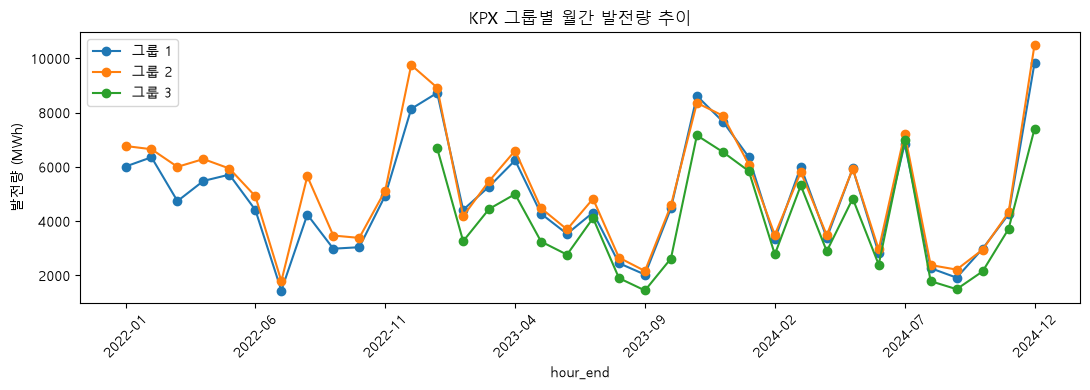

In [100]:
visualizer = WindPowerVisualizer()

# 그룹마다 어떤 시간별 표·컬럼을 쓸지 한 곳에 정리해두고 아래에서 계속 재사용한다
GROUP_SOURCE = {
    "그룹 1": (v_hourly, "kpx_group_1_power", "kpx_group_1_ws", "kpx_group_1_wd", "kpx_group_1"),
    "그룹 2": (v_hourly, "kpx_group_2_power", "kpx_group_2_ws", "kpx_group_2_wd", "kpx_group_2"),
    "그룹 3": (u_hourly, "kpx_group_3_power", "kpx_group_3_ws", "kpx_group_3_wd", "kpx_group_3"),
}
# 그룹3만 UNISON 표(u_hourly)를 써야 해서 헷갈리기 쉬운 부분을 여기 한 번만 적어둔다

monthly_power = {
    name: visualizer.transformToMonthlySum(hdf, power_col)
    for name, (hdf, power_col, _, _, _) in GROUP_SOURCE.items()
}
all_months = monthly_power["그룹 1"].index
# 그룹1 기준(2022-01~2024-12, 36개월)
monthly_power["그룹 3"] = monthly_power["그룹 3"].reindex(all_months)
# 그룹3에 없는 2022년 달은 0으로 채우지 않고 NaN으로 둔다 (없는 기간이지 결측이 아니다)

visualizer.plotSeriesByLabel(monthly_power, "KPX 그룹별 월간 발전량 추이", "발전량 (MWh)")

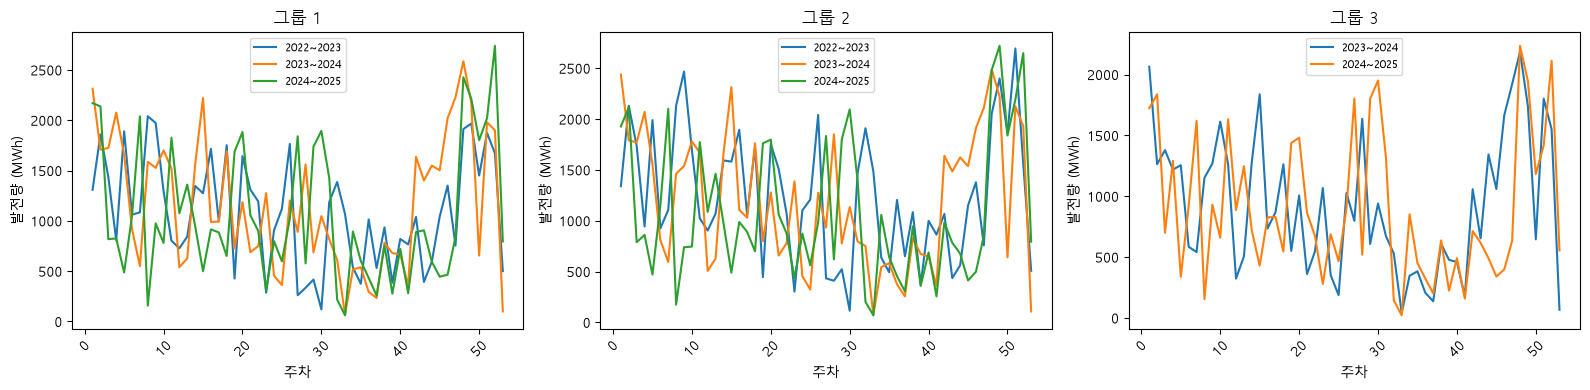

In [101]:
# 1년(1~12월)을 주 단위로 잘라 연도별로 겹쳐 그린다. 계절 패턴이 매년 반복되는지 확인
weekly_by_group = {
    name: visualizer.transformToWeeklyByYear(hdf, power_col, SEASON_YEARS)
    for name, (hdf, power_col, _, _, _) in GROUP_SOURCE.items()
}
visualizer.plotPanelByGroup(weekly_by_group, ylabel="발전량 (MWh)", xlabel="주차")

## Step 6. 풍속·풍향과 발전량의 관계

- **상관계수**(-1~1, 1에 가까울수록 같이 움직임)와 **설비이용률**(설비용량 대비 실제 발전 비율)로 확인
- 물리적으로 발전량은 풍속의 **세제곱**에 비례하므로 `발전량 / 풍속³`을 '풍속 대비 효율'로 보고,
  이 값이 풍향(8방위)에 따라 달라지면 터빈들이 서로의 바람을 가리는 **후류(wake) 효과**를 의심한다

In [102]:
class WindPowerAnalyzer(WindVectorTransformer):
    """발전량과 기상 변수의 관계 지표 계산을 담당하는 클래스

    Attributes:
        - 상관계수·설비이용률·방위별 효율은 SCADA 실측 기준
        - 예보 오차 지표(evaluateForecastResidual)는 LDAPS/GFS 후보를 고를 때 쓴다
    """

    def __init__(self, group_cap_kwh: Dict[str, float] = None):
        super().__init__()
        self.group_cap_kwh = group_cap_kwh if group_cap_kwh is not None else GROUP_CAP_KWH
        # KPX 그룹별 1시간 설비용량(kWh)

    def evaluateCorrelation(self, df: pd.DataFrame, power_col: str, ws_col: str) -> float:
        """발전량과 풍속의 피어슨 상관계수를 계산하는 메서드"""
        pair = df[[power_col, ws_col]].dropna()
        # 발전량·풍속이 둘 다 있는 시간만 사용
        return float(pair[power_col].corr(pair[ws_col]))

    def evaluateCapacityFactor(self, df: pd.DataFrame, power_col: str, ws_col: str, group: str) -> float:
        """설비이용률(%)을 계산하는 메서드

        Logic:
            - 설비이용률 = 실제 발전량 합 / (그룹 1시간 설비용량 x 유효 시간 수) x 100
            - 상관계수와 같은 표본을 쓰도록 풍속 결측 시간도 함께 제외한다
        """
        pair = df[[power_col, ws_col]].dropna()
        return float(pair[power_col].sum() / (self.group_cap_kwh[group] * len(pair)) * 100)

    def evaluateDirectionEfficiency(
        self,
        df: pd.DataFrame,
        power_col: str,
        ws_col: str,
        wd_col: str,
    ) -> pd.Series:
        """8방위별 '풍속 대비 발전 효율'을 계산하는 메서드

        Logic:
            - 발전량 / 풍속^3 을 효율 대리값으로 본다
            - 컷인 풍속 이하는 애초에 발전을 안 하므로 제외한다
            - 가장 좋은 방위를 100으로 놓고 상대 비교한다
        """
        part = df[[power_col, ws_col, wd_col]].dropna()
        part = part[part[ws_col] > CUT_IN_MS]
        coefficient = part[power_col] / (part[ws_col] ** 3)
        sector = (part[wd_col] // DIRECTION_SECTOR_DEG * DIRECTION_SECTOR_DEG).astype(int)
        # 풍향을 45도 단위 8방위(0, 45, ..., 315)로 묶는다
        efficiency = coefficient.groupby(sector).mean()
        return efficiency / efficiency.max() * 100

    def evaluateDirectionError(self, forecast_wd: pd.Series, actual_wd: pd.Series) -> float:
        """예보 풍향과 실측 풍향의 평균 절대 오차(도)를 계산하는 메서드

        Logic:
            - 풍향은 순환값이라 일반 상관계수를 쓰면 안 된다
            - 부모 클래스의 computeAngleDifference로 -180~180 최단 회전각을 구한 뒤 절댓값 평균
        """
        return float(self.computeAngleDifference(forecast_wd, actual_wd).abs().mean())

    def evaluateForecastResidual(self, actual: pd.Series, forecast: pd.Series) -> Dict[str, float]:
        """예보-실측 잔차의 오차 지표를 한 번에 계산하는 메서드

        Args:
            - actual   : SCADA 실측값 (m/s 또는 U/V 성분)
            - forecast : 같은 시각의 예보값

        Logic:
            - 평균편차(bias)는 상수 보정이나 모델 학습으로 줄일 수 있는 오차다
            - 편향보정 RMSE는 bias를 뺀 뒤 남는 흔들림이라 보정으로 줄일 수 없다
            - 그래서 예보 후보 선택은 원시 RMSE가 아니라 편향보정 RMSE로 해야 한다
        """
        pair = pd.DataFrame({"actual": actual, "forecast": forecast}).dropna()
        residual = pair["forecast"] - pair["actual"]
        # 양수면 예보가 실측보다 크게 나온 것
        bias = float(residual.mean())
        return {
            "표본수": len(pair),
            "상관계수": float(pair["actual"].corr(pair["forecast"])),
            "평균편차": bias,
            "MAE": float(residual.abs().mean()),
            "RMSE": float(np.sqrt((residual ** 2).mean())),
            "편향보정_RMSE": float(np.sqrt(((residual - bias) ** 2).mean())),
            "잔차_표준편차": float(residual.std()),
        }

    def summarize(self, df: pd.DataFrame, power_col: str, ws_col: str, group: str) -> Dict[str, float]:
        """한 그룹의 상관계수·설비이용률을 한 번에 반환하는 헬퍼 메서드"""
        return {
            "group": group,
            "corr": self.evaluateCorrelation(df, power_col, ws_col),
            "capacity_factor": self.evaluateCapacityFactor(df, power_col, ws_col, group),
        }

In [103]:
analyzer = WindPowerAnalyzer()

print("[정제 버전] 발전량-풍속 상관계수와 설비이용률")
for name, (hdf, power_col, ws_col, _, group) in GROUP_SOURCE.items():
    result = analyzer.summarize(hdf, power_col, ws_col, group)
    print(f"  {name}: 상관계수 = {result['corr']:.3f},  설비이용률 = {result['capacity_factor']:.1f}%")

# 원본(이상치 미처리) 버전과 비교. 극단값 몇 개가 상관계수를 얼마나 무너뜨리는지 확인
RAW_SOURCE = {
    "그룹 1": (v_hourly_raw, "kpx_group_1_power", "kpx_group_1_ws", "kpx_group_1"),
    "그룹 2": (v_hourly_raw, "kpx_group_2_power", "kpx_group_2_ws", "kpx_group_2"),
    "그룹 3": (u_hourly_raw, "kpx_group_3_power", "kpx_group_3_ws", "kpx_group_3"),
}
print()
print("[원본 버전] 이상치를 처리하지 않았을 때")
for name, (hdf, power_col, ws_col, group) in RAW_SOURCE.items():
    result = analyzer.summarize(hdf, power_col, ws_col, group)
    print(f"  {name}: 상관계수 = {result['corr']:.3f},  설비이용률 = {result['capacity_factor']:.1f}%")

[정제 버전] 발전량-풍속 상관계수와 설비이용률
  그룹 1: 상관계수 = 0.927,  설비이용률 = 30.9%
  그룹 2: 상관계수 = 0.939,  설비이용률 = 32.9%
  그룹 3: 상관계수 = 0.907,  설비이용률 = 26.3%

[원본 버전] 이상치를 처리하지 않았을 때
  그룹 1: 상관계수 = 0.004,  설비이용률 = 30.9%
  그룹 2: 상관계수 = 0.004,  설비이용률 = 32.9%
  그룹 3: 상관계수 = 0.909,  설비이용률 = 26.4%


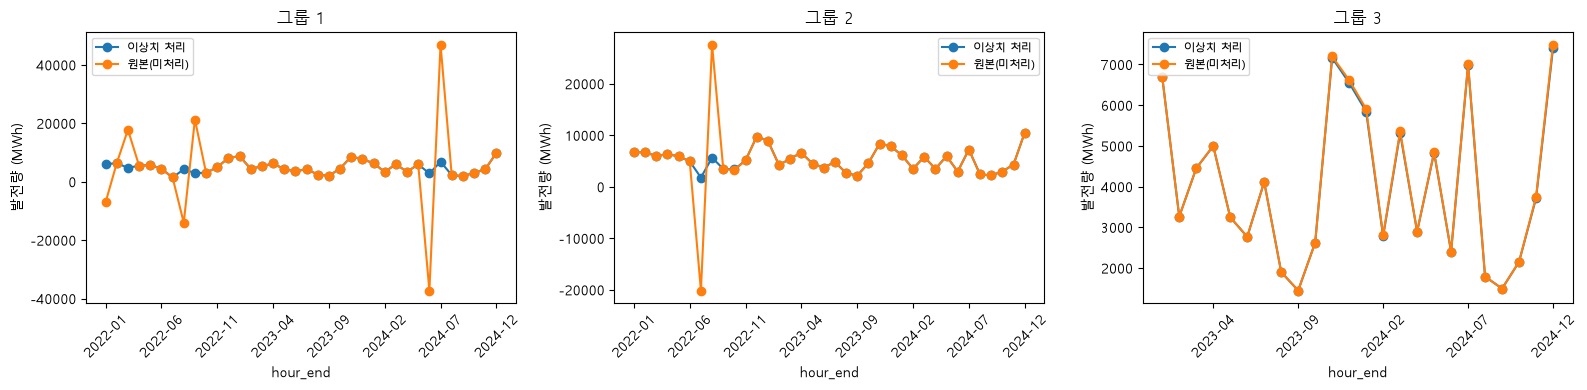

월별 발전량 차이 (원본 - 정제). 총량은 거의 안 변한다


,그룹 1_차이(MWh),그룹 2_차이(MWh),그룹 3_차이(MWh)
hour_end,,,
2022-01,-13044.859,0.000,NaN
2022-02,-0.008,-0.007,NaN
2022-03,13045.392,-0.006,NaN
2022-04,-0.006,0.000,NaN
2022-05,0.513,-0.010,NaN
2022-06,0.095,-0.002,NaN
2022-07,0.000,-21930.636,NaN
2022-08,-18294.585,21930.994,NaN
2022-09,18294.586,0.088,NaN


In [104]:
# 월간 발전량은 정제 전후가 거의 같은지 (총량 관점에서 이상치 영향이 있는지) 확인
monthly_power_raw = {
    "그룹 1": visualizer.transformToMonthlySum(v_hourly_raw, "kpx_group_1_power"),
    "그룹 2": visualizer.transformToMonthlySum(v_hourly_raw, "kpx_group_2_power"),
    "그룹 3": visualizer.transformToMonthlySum(u_hourly_raw, "kpx_group_3_power").reindex(all_months),
}

visualizer.plotPanelByGroup(
    {name: {"이상치 처리": monthly_power[name], "원본(미처리)": monthly_power_raw[name]} for name in GROUP_SOURCE},
    ylabel="발전량 (MWh)",
    marker="o",
)

diff_table = pd.DataFrame({
    f"{name}_차이(MWh)": monthly_power_raw[name] - monthly_power[name] for name in GROUP_SOURCE
})
print("월별 발전량 차이 (원본 - 정제). 총량은 거의 안 변한다")
diff_table.head(12)

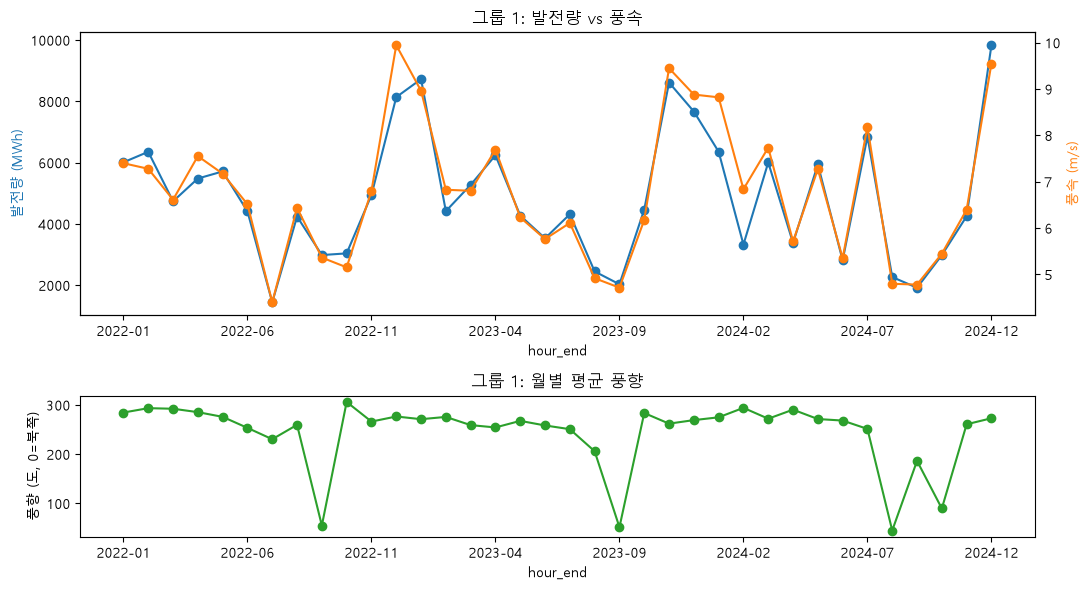

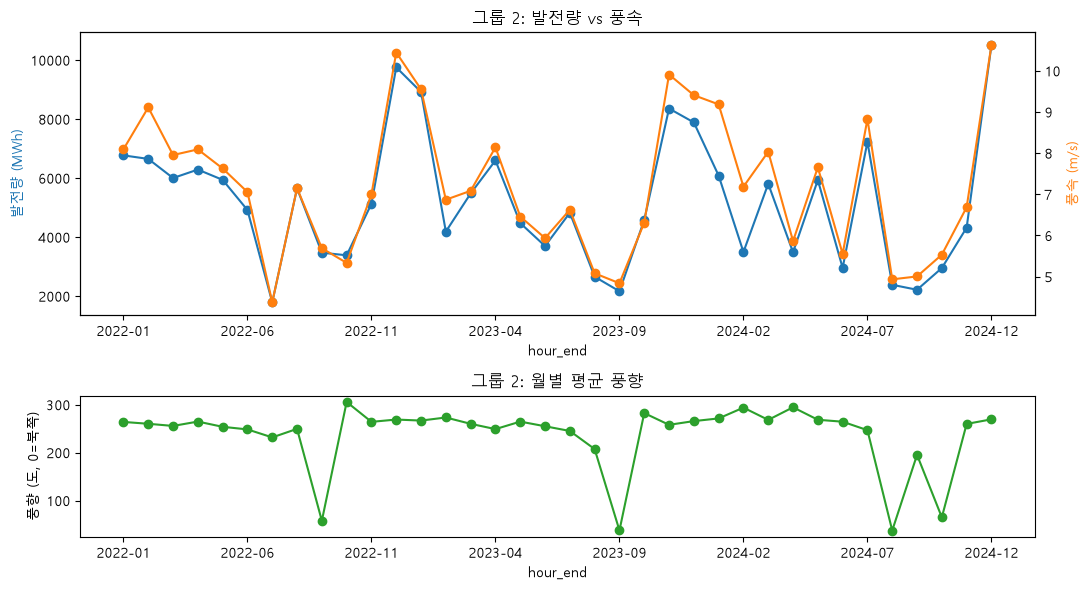

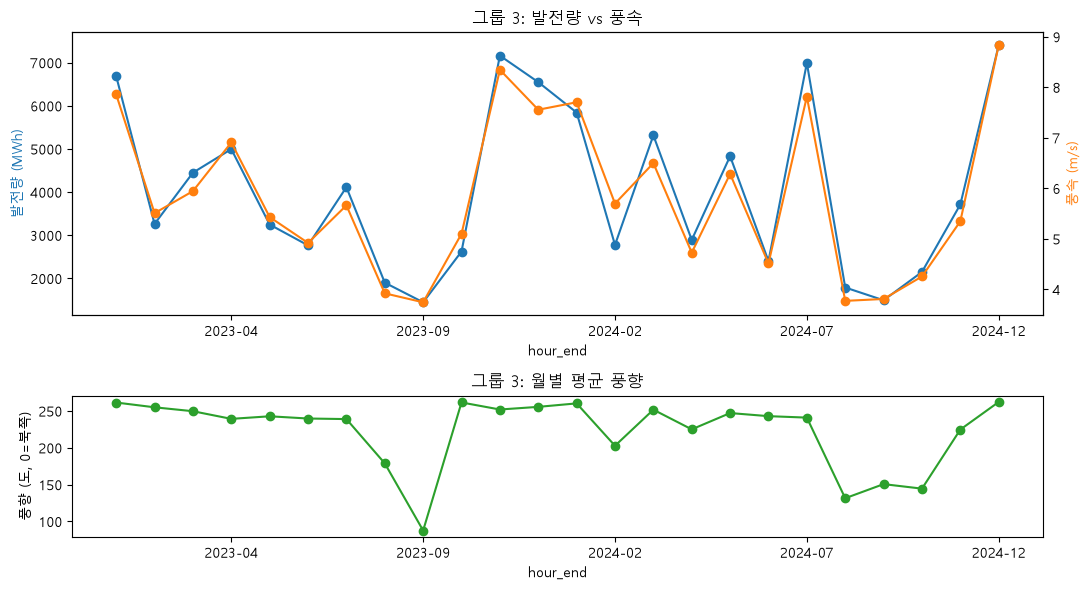

In [105]:
# 발전량 vs 풍속(twinx) + 월별 평균 풍향
for name, (hdf, power_col, ws_col, wd_col, _) in GROUP_SOURCE.items():
    visualizer.plotPowerVersusWind(monthly_power[name], hdf, ws_col, wd_col, name)

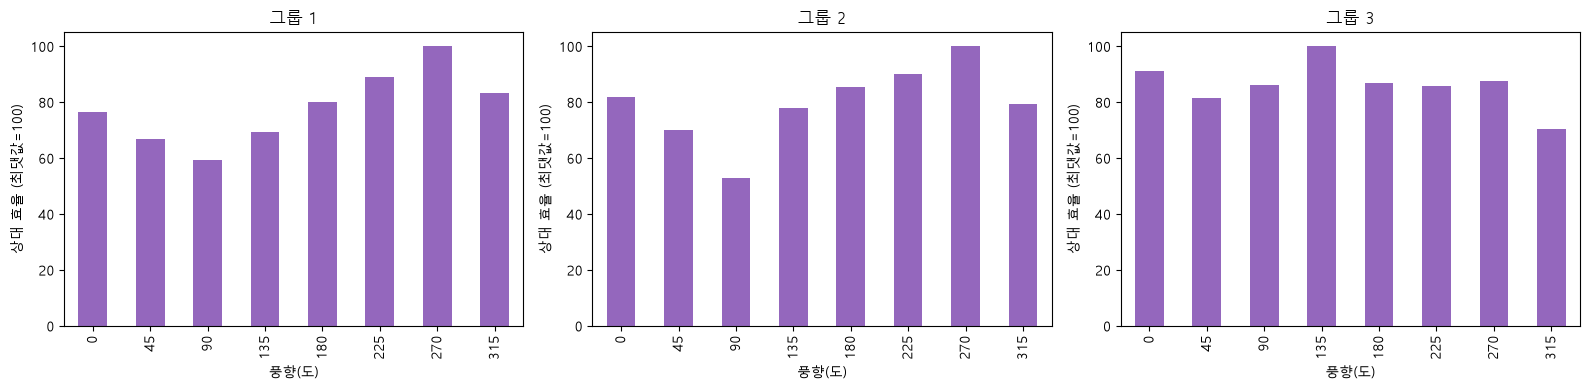

방위별 상대 효율 (최댓값=100)


,그룹 1,그룹 2,그룹 3
0,76.5,81.9,91.3
45,66.7,70.0,81.7
90,59.4,52.9,86.2
135,69.5,77.8,100.0
180,79.9,85.4,86.7
225,89.2,90.0,85.8
270,100.0,100.0,87.6
315,83.1,79.2,70.4


In [106]:
# 8방위별 상대 효율. 방위마다 크게 다르면 후류(wake) 효과를 의심한다
efficiency_by_group = {
    name: analyzer.evaluateDirectionEfficiency(hdf, power_col, ws_col, wd_col)
    for name, (hdf, power_col, ws_col, wd_col, _) in GROUP_SOURCE.items()
}
visualizer.plotBarByGroup(efficiency_by_group, ylabel="상대 효율 (최댓값=100)", xlabel="풍향(도)")

print("방위별 상대 효율 (최댓값=100)")
pd.DataFrame(efficiency_by_group).round(1)

**Step 6 정리**

- 월별 발전량은 겨울(11~1월)에 높고 늦여름(8~9월)에 낮은 패턴이 **3개년 모두 반복**된다
- SCADA 실측 풍속과 발전량 상관계수는 0.907~0.939. 풍속 세제곱보다 풍속 원본이 더 잘 맞았는데,
  정격 이후 포화되는 파워커브 때문으로 보인다
- 풍향에 따라 효율이 최대 2배 가까이 차이 난다(그룹1·2). 후류 효과로 추정되므로 풍향은 꼭 피처로 넣는다
- 이상치 처리 여부로 월간 총량은 거의 안 변하는데, 그룹1·2의 상관계수는 0.93 → 0.004로 무너진다.
  **결측률만 보고 "깨끗하다"고 판단하면 안 된다**
- 그룹3(UNISON)은 원본도 0.909로 정제 버전(0.907)과 거의 같다. 애초에 NaN이 많아 극단값이 적었기 때문

## Step 7. 예보(LDAPS/GFS) 대표값 계산 및 실측 비교

실제 예측 상황에서는 SCADA 실측값을 쓸 수 없고 **기상 예보 데이터만** 사용한다.
`ldaps_train.csv`, `gfs_train.csv` 둘 다 '풍속'·'풍향' 컬럼이 없으므로 지상 10m U/V 성분에서 계산한 뒤
SCADA 실측과 비교한다. 같은 방식으로 계산해야 LDAPS와 GFS를 공정하게 비교할 수 있다.

풍향 계산 참고: https://randroll.wordpress.com/2022/05/03/wind-direction-from-wind-components/

In [107]:
class ForecastAggregator(WindVectorTransformer):
    """격자 단위 예보(LDAPS/GFS)를 시각별 지역 대표값으로 집계하는 클래스

    Attributes:
        - LDAPS : 약 1.5km 공간해상도의 16개 격자
        - GFS   : 약 0.25도 공간해상도의 9개 격자
        - 격자 수가 달라도 같은 방식(성분 -> 풍속·풍향 -> 원형 평균)으로 처리해야 공정한 비교가 된다
    """

    def __init__(self, time_col: str = "forecast_kst_dtm"):
        super().__init__()
        self.time_col = time_col
        # 예보 대상 시각 컬럼명

    def transformGridWind(self, df: pd.DataFrame, u_col: str, v_col: str) -> pd.DataFrame:
        """격자별 u/v 성분에서 풍속·풍향을 복원하는 메서드"""
        df = df.copy()
        df[self.time_col] = pd.to_datetime(df[self.time_col])
        # 시간 컬럼을 날짜/시간 타입으로 통일
        df["ws10"] = self.computeWindSpeed(df[u_col], df[v_col])
        df["wd10"] = self.computeWindDirection(df[u_col], df[v_col])
        return df

    def transformToHourly(self, df: pd.DataFrame, ws_col: str = "ws10", wd_col: str = "wd10") -> pd.DataFrame:
        """격자를 평균해 시각별 지역 대표 풍속·풍향을 만드는 메서드

        Logic:
            - 풍속은 산술 평균
            - 풍향은 격자별 sin/cos을 평균한 뒤 각도로 복원한다 (원형 평균)
        """
        ws_hourly = df.groupby(self.time_col)[ws_col].mean()

        radian = np.deg2rad(df[wd_col])
        sin_hourly = np.sin(radian).groupby(df[self.time_col]).mean()
        cos_hourly = np.cos(radian).groupby(df[self.time_col]).mean()
        wd_hourly = (np.degrees(np.arctan2(sin_hourly, cos_hourly)) + 360) % 360

        return pd.DataFrame({"ws": ws_hourly, "wd": wd_hourly})
        # 인덱스 = 예보 대상 시각, 컬럼 = ws / wd

    def transformToGridMean(self, df: pd.DataFrame, cols: List[str], rename_map: Dict[str, str]) -> pd.DataFrame:
        """원본 U/V 컬럼을 가공 없이 시각별 격자 평균으로 묶는 메서드

        Logic:
            - Step 8에서 예보 '원본 성분'과 SCADA 성분을 직접 비교하기 위해
              풍속으로 바꾸지 않고 컬럼 그대로 평균만 낸다
        """
        hourly = df.groupby(self.time_col)[cols].mean()
        return hourly.rename(columns=rename_map)

In [108]:
forecast_aggregator = ForecastAggregator()

# LDAPS: 풍속·풍향 비교에 필요한 컬럼 + 공기밀도 계산에 필요한 기온·비습·기압만 읽는다
LDAPS_USECOLS = [
    "forecast_kst_dtm",
    "heightAboveGround_10_10u", "heightAboveGround_10_10v",
    "heightAboveGround_2_t", "heightAboveGround_2_q", "surface_0_sp",
]
ldaps = loader.load("ldaps_train", usecols=LDAPS_USECOLS)
ldaps = forecast_aggregator.transformGridWind(ldaps, "heightAboveGround_10_10u", "heightAboveGround_10_10v")
ldaps_hourly = forecast_aggregator.transformToHourly(ldaps)
# 16개 격자를 평균해 시각별 지역 대표값으로

# GFS: LDAPS와 똑같은 방식으로 처리
GFS_USECOLS = ["forecast_kst_dtm", "heightAboveGround_10_10u", "heightAboveGround_10_10v"]
gfs = loader.load("gfs_train", usecols=GFS_USECOLS)
gfs = forecast_aggregator.transformGridWind(gfs, "heightAboveGround_10_10u", "heightAboveGround_10_10v")
gfs_hourly = forecast_aggregator.transformToHourly(gfs)
# 9개 격자를 평균해 시각별 지역 대표값으로

print("LDAPS 격자별 풍속/풍향")
print(ldaps[["ws10", "wd10"]].describe().round(3).to_string())
print()
print("GFS 격자별 풍속/풍향")
print(gfs[["ws10", "wd10"]].describe().round(3).to_string())

LDAPS 격자별 풍속/풍향
             ws10        wd10
count  420864.000  420864.000
mean        4.836     209.187
std         2.612      85.659
min         0.006       0.002
25%         2.891     131.709
50%         4.307     253.881
75%         6.386     268.560
max        18.412     359.993

GFS 격자별 풍속/풍향
             ws10        wd10
count  236736.000  236736.000
mean        2.607     206.425
std         1.765      92.619
min         0.005       0.006
25%         1.420     139.535
50%         2.183     242.518
75%         3.294     265.562
max        25.761     359.994


In [109]:
# 공기밀도 계산. 발전량이 밀도 x 풍속^3에 비례하므로 피처 후보가 된다
ldaps = forecast_aggregator.calculateAirDensity(
    ldaps,
    t_col="heightAboveGround_2_t",
    # 지상 2m 기온 (K)
    q_col="heightAboveGround_2_q",
    # 지상 2m 비습 (kg/kg)
    p_col="surface_0_sp",
    # 지표면 기압 (Pa)
)

print("공기밀도 계산 결과 (표준 대기 1.225 kg/m³ 근처여야 정상)")
print("태백 산지 900m 고도라 표준보다 조금 낮게 나오는 것이 맞다")
print(ldaps[["surface_0_sp", "heightAboveGround_2_t", "heightAboveGround_2_q", "e_pa", "air_density"]].describe().T[["min", "mean", "max"]].round(5))

공기밀도 계산 결과 (표준 대기 1.225 kg/m³ 근처여야 정상)
태백 산지 900m 고도라 표준보다 조금 낮게 나오는 것이 맞다
                               min         mean          max
surface_0_sp           87462.81000  90673.49186  93083.13000
heightAboveGround_2_t    249.69829    281.16928    302.91513
heightAboveGround_2_q      0.00024      0.00702      0.02125
e_pa                      35.06595   1015.42684   3031.59792
air_density                1.02241      1.12048      1.26723


In [110]:
# 그룹별로 SCADA 실측과 LDAPS·GFS 예보를 같은 시각끼리 붙여 비교한다
compare_by_group = {}
forecast_rows = []

for name, (hdf, power_col, ws_col, wd_col, group) in GROUP_SOURCE.items():
    compare = (
        hdf.set_index("hour_end")[[power_col, ws_col, wd_col]]
        .join(ldaps_hourly.rename(columns={"ws": "ldaps_ws10", "wd": "ldaps_wd10"}))
        .join(gfs_hourly.rename(columns={"ws": "gfs_ws10", "wd": "gfs_wd10"}))
        .dropna()
    )
    # 발전량·실측풍속·실측풍향에 두 예보의 풍속·풍향을 같은 시각끼리 연결
    compare_by_group[name] = compare
    # 뒤 그래프 셀에서 재사용

    forecast_rows.append({
        "그룹": name,
        "발전량-LDAPS풍속 상관": analyzer.evaluateCorrelation(compare, power_col, "ldaps_ws10"),
        "발전량-GFS풍속 상관": analyzer.evaluateCorrelation(compare, power_col, "gfs_ws10"),
        "발전량-SCADA풍속 상관": analyzer.evaluateCorrelation(compare, power_col, ws_col),
        # 실측 풍속 상관은 예보로 도달할 수 있는 상한선 역할을 한다
        "LDAPS풍향 MAE(도)": analyzer.evaluateDirectionError(compare["ldaps_wd10"], compare[wd_col]),
        "GFS풍향 MAE(도)": analyzer.evaluateDirectionError(compare["gfs_wd10"], compare[wd_col]),
    })

forecast_report = pd.DataFrame(forecast_rows)
print("예보 풍속·풍향의 설명력 (실측 상관이 상한선)")
forecast_report.round(3)

예보 풍속·풍향의 설명력 (실측 상관이 상한선)


,그룹,발전량-LDAPS풍속 상관,발전량-GFS풍속 상관,발전량-SCADA풍속 상관,LDAPS풍향 MAE(도),GFS풍향 MAE(도)
0,그룹 1,0.730,0.539,0.927,24.270,31.889
1,그룹 2,0.739,0.548,0.939,23.103,28.654
2,그룹 3,0.732,0.545,0.907,24.530,29.915


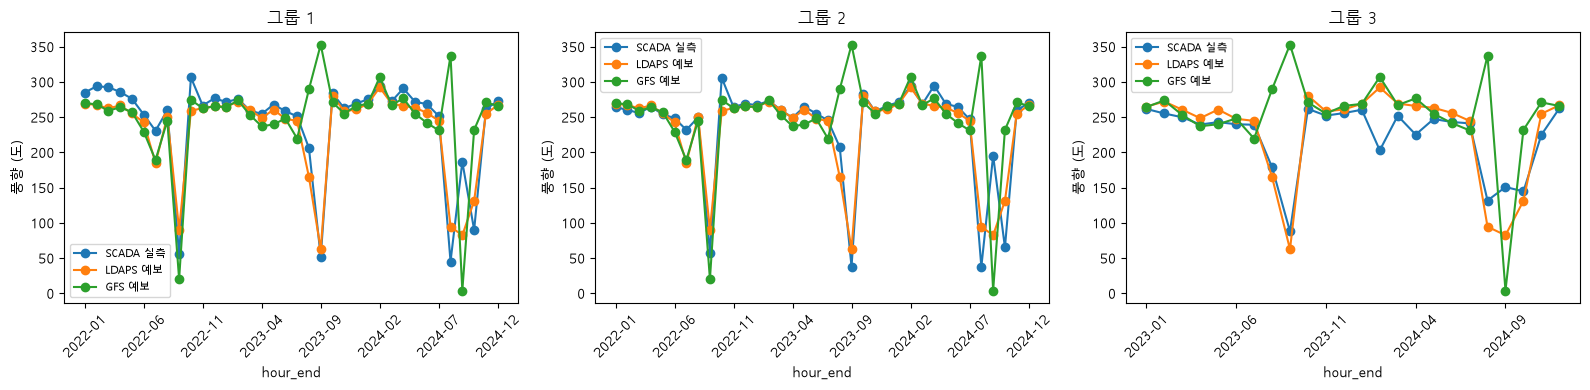

In [111]:
# 월별 평균 풍향을 SCADA·LDAPS·GFS 세 계열로 겹쳐 본다
direction_panel = {}
for name, (hdf, power_col, ws_col, wd_col, group) in GROUP_SOURCE.items():
    compare = compare_by_group[name]
    year_month = compare.index.to_period("M").astype(str)
    direction_panel[name] = {
        "SCADA 실측": compare[wd_col].groupby(year_month).apply(transformer.computeCircularMean),
        "LDAPS 예보": compare["ldaps_wd10"].groupby(year_month).apply(transformer.computeCircularMean),
        "GFS 예보": compare["gfs_wd10"].groupby(year_month).apply(transformer.computeCircularMean),
    }

visualizer.plotPanelByGroup(direction_panel, ylabel="풍향 (도)", marker="o")

## Step 8. 예보 U/V 편차·계절성 비교

Step 7에서는 예보를 풍속·풍향으로 바꿔서 비교했다. 여기서는 **가공하지 않은 원본 U/V 컬럼**을
SCADA U/V와 직접 비교한다. 고도별 후보(LDAPS 10m·50m, GFS 10m·80m·100m) 중 어느 것을 1차 피처로
쓸지 고르는 것이 목적이다.

핵심은 **원시 RMSE가 아니라 편향보정 RMSE로 골라야 한다**는 점이다.
- 평균편차(bias)는 상수 보정이나 모델 학습으로 줄일 수 있지만, 잔차의 변동성은 줄일 수 없음

In [112]:
# SCADA 그룹 시간별 풍속·풍향을 U/V 성분으로 바꿔 한 표로 모은다
scada_uv_hourly = pd.concat(
    [
        scada_aggregator.transformToUVTable(hdf, group, ws_col, wd_col)
        for _, (hdf, _, ws_col, wd_col, group) in GROUP_SOURCE.items()
    ],
    ignore_index=True,
)

# 예보 원본 U/V 컬럼을 가공 없이 시각별 격자 평균으로 묶는다
ldaps_uv_hourly = forecast_aggregator.transformToGridMean(
    loader.load(
        "ldaps_train",
        force=True,
        usecols=[
            "forecast_kst_dtm",
            "heightAboveGround_10_10u", "heightAboveGround_10_10v",
            "heightAboveGround_50_50MUmax", "heightAboveGround_50_50MUmin",
            "heightAboveGround_50_50MVmax", "heightAboveGround_50_50MVmin",
        ],
    ).assign(forecast_kst_dtm=lambda d: pd.to_datetime(d["forecast_kst_dtm"])),
    cols=[
        "heightAboveGround_10_10u", "heightAboveGround_10_10v",
        "heightAboveGround_50_50MUmax", "heightAboveGround_50_50MUmin",
        "heightAboveGround_50_50MVmax", "heightAboveGround_50_50MVmin",
    ],
    rename_map={
        "heightAboveGround_10_10u": "ldaps_u10",
        "heightAboveGround_10_10v": "ldaps_v10",
        "heightAboveGround_50_50MUmax": "ldaps_u50_max",
        "heightAboveGround_50_50MUmin": "ldaps_u50_min",
        "heightAboveGround_50_50MVmax": "ldaps_v50_max",
        "heightAboveGround_50_50MVmin": "ldaps_v50_min",
    },
)

gfs_uv_hourly = forecast_aggregator.transformToGridMean(
    loader.load(
        "gfs_train",
        force=True,
        usecols=[
            "forecast_kst_dtm",
            "heightAboveGround_10_10u", "heightAboveGround_10_10v",
            "heightAboveGround_80_u", "heightAboveGround_80_v",
            "heightAboveGround_100_100u", "heightAboveGround_100_100v",
        ],
    ).assign(forecast_kst_dtm=lambda d: pd.to_datetime(d["forecast_kst_dtm"])),
    cols=[
        "heightAboveGround_10_10u", "heightAboveGround_10_10v",
        "heightAboveGround_80_u", "heightAboveGround_80_v",
        "heightAboveGround_100_100u", "heightAboveGround_100_100v",
    ],
    rename_map={
        "heightAboveGround_10_10u": "gfs_u10",
        "heightAboveGround_10_10v": "gfs_v10",
        "heightAboveGround_80_u": "gfs_u80",
        "heightAboveGround_80_v": "gfs_v80",
        "heightAboveGround_100_100u": "gfs_u100",
        "heightAboveGround_100_100v": "gfs_v100",
    },
)

# 그룹별 SCADA U/V에 예보 원본 U/V를 붙여 비교표를 만든다
uv_compare = pd.concat(
    [
        part.set_index("forecast_kst_dtm")[["scada_u", "scada_v"]]
        .join(ldaps_uv_hourly)
        .join(gfs_uv_hourly)
        .dropna()
        .assign(group=group)
        .reset_index()
        for group, part in scada_uv_hourly.groupby("group")
    ],
    ignore_index=True,
)

print(f"U/V 비교표: {len(uv_compare):,}행")
uv_compare.head(3)

U/V 비교표: 70,141행


,forecast_kst_dtm,scada_u,scada_v,ldaps_u10,ldaps_v10,ldaps_u50_max,ldaps_u50_min,ldaps_v50_max,ldaps_v50_min,gfs_u10,gfs_v10,gfs_u80,gfs_v80,gfs_u100,gfs_v100,group
0,2022-01-01 01:00:00,7.852875,-2.473890,5.297585,-0.173397,8.421367,7.729351,0.158442,-0.198080,2.106355,0.386735,2.697944,0.285978,2.758286,0.265433,kpx_group_1
1,2022-01-01 02:00:00,8.023828,-2.969126,4.346036,-0.407328,8.261779,6.641635,0.045467,-0.761471,2.097211,0.459929,2.666660,0.408634,2.713932,0.399526,kpx_group_1
2,2022-01-01 03:00:00,7.888002,-2.519329,4.191131,-0.210821,6.637347,5.875278,-0.297825,-0.642738,2.038630,0.441868,2.596868,0.409222,2.649841,0.405759,kpx_group_1


In [113]:
# U는 U끼리, V는 V끼리 비교한다. 후보 컬럼을 한 곳에 정의해두고 아래에서 재사용
FORECAST_CANDIDATE = {
    "scada_u": ["ldaps_u10", "ldaps_u50_max", "ldaps_u50_min", "gfs_u10", "gfs_u80", "gfs_u100"],
    "scada_v": ["ldaps_v10", "ldaps_v50_max", "ldaps_v50_min", "gfs_v10", "gfs_v80", "gfs_v100"],
}

uv_report = pd.DataFrame([
    {"group": group, "SCADA 성분": scada_col, "예보 원본 컬럼": forecast_col,
     **analyzer.evaluateForecastResidual(part[scada_col], part[forecast_col])}
    for group, part in uv_compare.groupby("group")
    for scada_col, candidates in FORECAST_CANDIDATE.items()
    for forecast_col in candidates
])

print("SCADA U/V 대비 예보 U/V 편차 지표 (전체 기간)")
print(uv_report.round(3).to_string(index=False))

SCADA U/V 대비 예보 U/V 편차 지표 (전체 기간)
      group SCADA 성분      예보 원본 컬럼   표본수  상관계수   평균편차   MAE  RMSE  편향보정_RMSE  잔차_표준편차
kpx_group_1  scada_u     ldaps_u10 26303 0.905 -1.489 2.383 2.992      2.595    2.595
kpx_group_1  scada_u ldaps_u50_max 26303 0.900  0.468 2.178 2.846      2.807    2.807
kpx_group_1  scada_u ldaps_u50_min 26303 0.903 -0.623 2.191 2.832      2.762    2.762
kpx_group_1  scada_u       gfs_u10 26303 0.814 -2.991 4.486 5.196      4.250    4.250
kpx_group_1  scada_u       gfs_u80 26303 0.814 -2.300 3.665 4.314      3.649    3.649
kpx_group_1  scada_u      gfs_u100 26303 0.815 -2.203 3.556 4.198      3.574    3.574
kpx_group_1  scada_v     ldaps_v10 26303 0.723  0.431 1.432 1.880      1.830    1.830
kpx_group_1  scada_v ldaps_v50_max 26303 0.735  1.151 1.796 2.368      2.069    2.070
kpx_group_1  scada_v ldaps_v50_min 26303 0.715  0.162 1.586 2.100      2.094    2.094
kpx_group_1  scada_v       gfs_v10 26303 0.632  0.183 1.604 2.092      2.084    2.084
kpx_group_1  scada_v

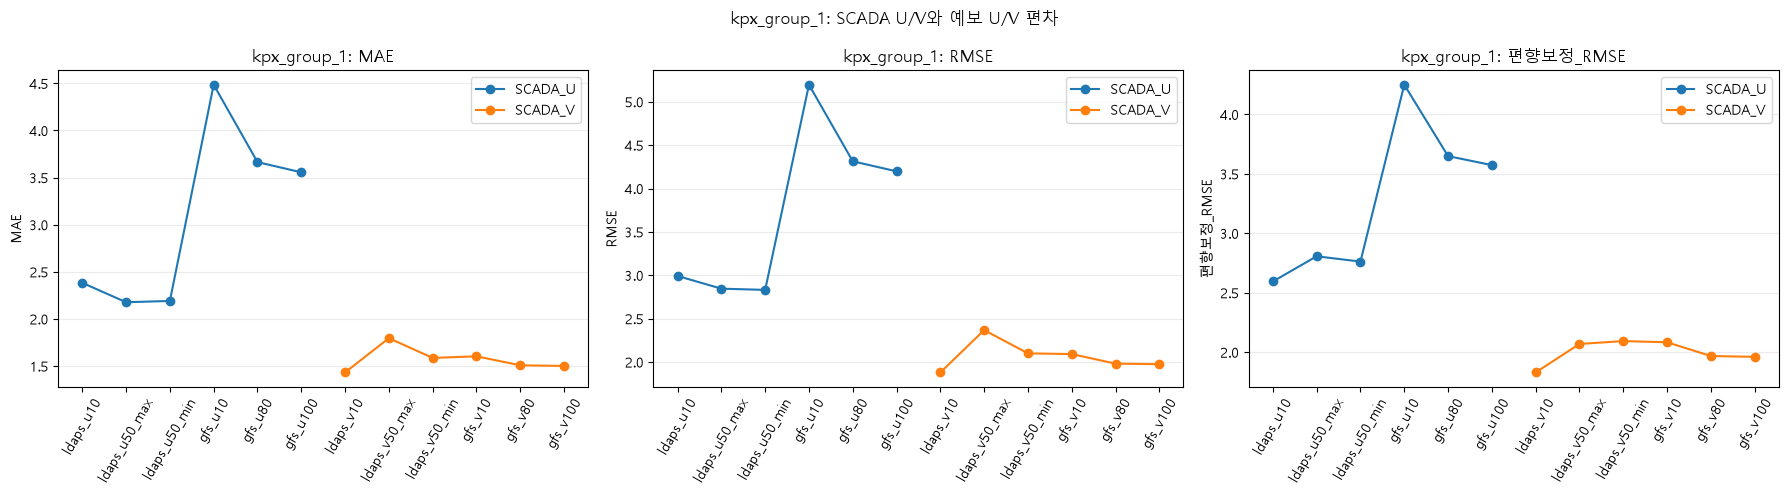

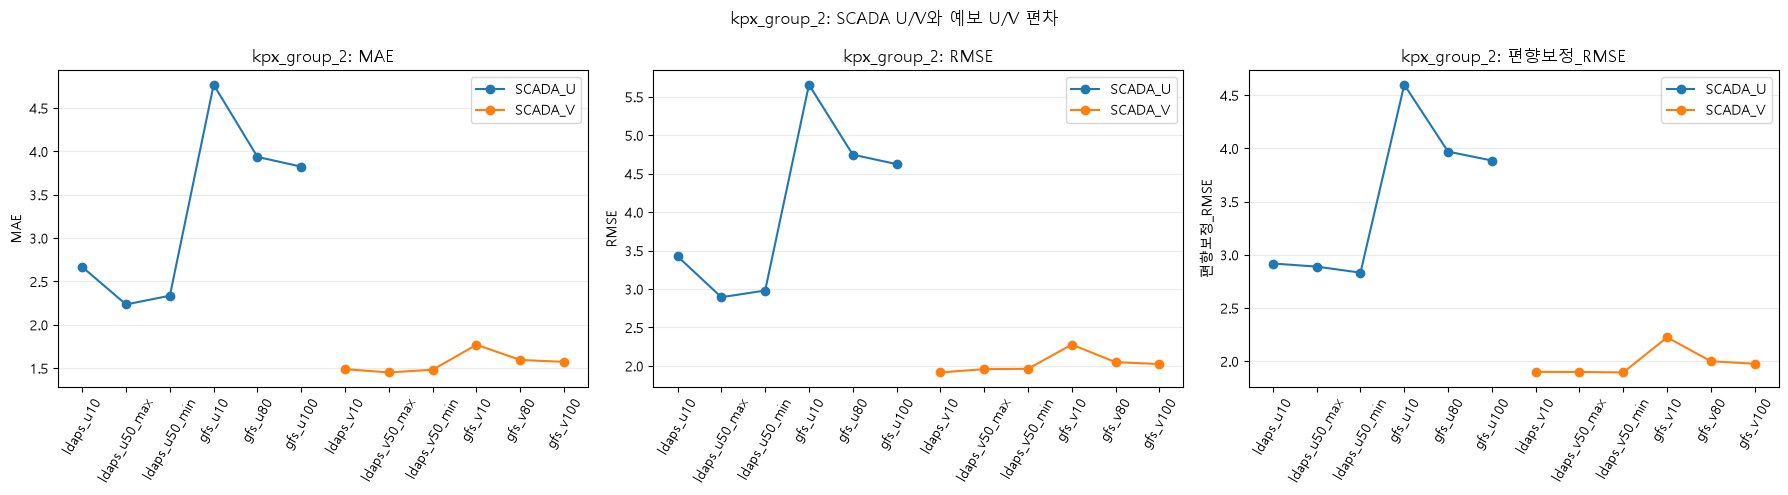

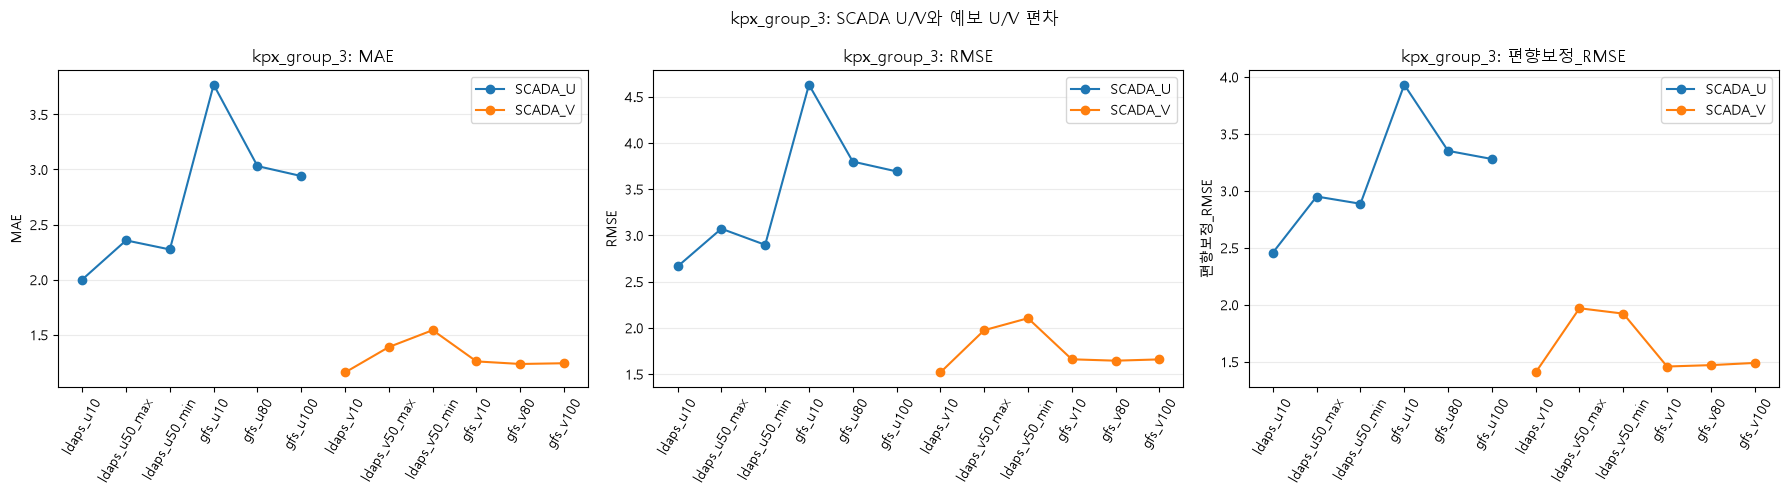

In [114]:
# MAE·RMSE·편향보정 RMSE는 값의 크기가 달라서 한 그림에 겹치면 안 보인다. 지표별로 따로 그린다
ERROR_METRICS = ["MAE", "RMSE", "편향보정_RMSE"]

for group, group_part in uv_report.groupby("group"):
    fig, axes = plt.subplots(1, len(ERROR_METRICS), figsize=(18, 5))
    for ax, metric in zip(axes, ERROR_METRICS):
        for scada_col, color in [("scada_u", "tab:blue"), ("scada_v", "tab:orange")]:
            part = group_part[group_part["SCADA 성분"] == scada_col]
            ax.plot(part["예보 원본 컬럼"], part[metric], marker="o", color=color, label=scada_col.upper())
        ax.set_title(f"{group}: {metric}")
        ax.set_ylabel(metric)
        ax.tick_params(axis="x", rotation=60)
        # 예보 컬럼명이 길어서 눕혀 표시
        ax.grid(axis="y", alpha=0.25)
        ax.legend()
    plt.suptitle(f"{group}: SCADA U/V와 예보 U/V 편차")
    plt.tight_layout()
    plt.show()

In [115]:
# 바람은 계절마다 성질이 다르므로 하절기(6~8월)·동절기(12~2월)를 나눠 다시 계산한다
seasonal = uv_compare.copy()
seasonal["season"] = seasonal["forecast_kst_dtm"].dt.month.map(SEASON_MONTH)
seasonal = seasonal[seasonal["season"].notna()]
# 봄·가을(환절기)은 제외

seasonal_report = pd.DataFrame([
    {"group": group, "season": season, "SCADA 성분": scada_col, "예보 원본 컬럼": forecast_col,
     **analyzer.evaluateForecastResidual(part[scada_col], part[forecast_col])}
    for (group, season), part in seasonal.groupby(["group", "season"])
    for scada_col, candidates in FORECAST_CANDIDATE.items()
    for forecast_col in candidates
])
seasonal_report["예보모델"] = np.where(
    seasonal_report["예보 원본 컬럼"].str.startswith("ldaps_"), "LDAPS", "GFS"
)
# 컬럼명 접두사로 어느 예보 모델인지 구분

print("[계절·성분·예보모델별 평균 성능]")
model_summary = (
    seasonal_report
    .groupby(["season", "SCADA 성분", "예보모델"])[["상관계수", "MAE", "RMSE", "편향보정_RMSE", "잔차_표준편차"]]
    .mean()
    .reset_index()
    .sort_values(["season", "SCADA 성분", "편향보정_RMSE"])
)
print(model_summary.round(3).to_string(index=False))

[계절·성분·예보모델별 평균 성능]
season SCADA 성분  예보모델  상관계수   MAE  RMSE  편향보정_RMSE  잔차_표준편차
   동절기  scada_u LDAPS 0.898 2.397 3.029      2.736    2.736
   동절기  scada_u   GFS 0.800 4.630 5.342      3.827    3.828
   동절기  scada_v LDAPS 0.691 1.420 1.880      1.737    1.737
   동절기  scada_v   GFS 0.624 1.490 1.931      1.780    1.780
   하절기  scada_u LDAPS 0.878 2.196 2.885      2.713    2.713
   하절기  scada_u   GFS 0.800 3.379 4.147      3.523    3.524
   하절기  scada_v   GFS 0.728 1.400 1.860      1.783    1.783
   하절기  scada_v LDAPS 0.770 1.473 1.987      1.888    1.888


In [116]:
# 그룹·계절·성분마다 오차가 가장 작았던 후보를 두 기준으로 각각 뽑아 순위가 뒤집히는지 확인
for metric, title in [("RMSE", "원시 RMSE"), ("편향보정_RMSE", "편향 보정 RMSE")]:
    best = (
        seasonal_report
        .sort_values(metric)
        .groupby(["group", "season", "SCADA 성분"], as_index=False)
        .first()
        # 정렬된 상태에서 첫 줄이 오차 최소 후보
    )
    print(f"\n[{title} 기준 최선 후보]")
    print(best[["group", "season", "SCADA 성분", "예보 원본 컬럼", metric, "상관계수", "평균편차"]].round(3).to_string(index=False))


[원시 RMSE 기준 최선 후보]
      group season SCADA 성분      예보 원본 컬럼  RMSE  상관계수   평균편차
kpx_group_1    동절기  scada_u ldaps_u50_min 2.669 0.900 -0.245
kpx_group_1    동절기  scada_v      gfs_v100 2.057 0.556  0.618
kpx_group_1    하절기  scada_u     ldaps_u10 2.832 0.876 -1.318
kpx_group_1    하절기  scada_v     ldaps_v10 1.660 0.762 -0.003
kpx_group_2    동절기  scada_u ldaps_u50_max 2.867 0.887 -0.039
kpx_group_2    동절기  scada_v ldaps_v50_max 1.703 0.760  0.281
kpx_group_2    하절기  scada_u ldaps_u50_max 2.829 0.879  0.270
kpx_group_2    하절기  scada_v     ldaps_v10 1.905 0.785 -0.385
kpx_group_3    동절기  scada_u ldaps_u50_min 2.737 0.905  0.216
kpx_group_3    동절기  scada_v     ldaps_v10 1.451 0.708 -0.623
kpx_group_3    하절기  scada_u     ldaps_u10 2.507 0.879 -1.078
kpx_group_3    하절기  scada_v     ldaps_v10 1.519 0.752 -0.506

[편향 보정 RMSE 기준 최선 후보]
      group season SCADA 성분      예보 원본 컬럼  편향보정_RMSE  상관계수   평균편차
kpx_group_1    동절기  scada_u     ldaps_u10      2.548 0.901 -2.106
kpx_group_1    동절기  scada_v     

**Step 8 정리**

**U 성분(동서 바람)은 LDAPS 우세**

- 전체 기간 상관계수가 LDAPS 0.90 안팎, GFS 0.81 안팎이고 RMSE도 LDAPS 2.8~3.4 / GFS 4.2~5.7로 차이가 크다
- GFS의 U는 평균편차가 -2.2 ~ -3.3으로 **일관되게 SCADA보다 약하게** 나온다.
  Step 7에서 본 GFS 10m 평균 풍속(2.61m/s)이 LDAPS(4.84m/s)보다 훨씬 낮았던 것과 같은 얘기다
- 고도를 올리면(10m→80m→100m) GFS 오차가 줄지만(그룹1 RMSE 5.20→4.31→4.20) LDAPS 10m는 못 이긴다

**V 성분(남북 바람)은 비슷함**

- 상관계수 자체가 U보다 낮다(0.63~0.79). 이 지역 바람이 서풍 위주라 V는 신호가 약한 듯하다
- 그룹1은 `gfs_v100`(1.975)이 `ldaps_v10`(1.880)과 거의 붙었고, 그룹3도 `gfs_v10`(1.659)이 바로 뒤다.
  V는 GFS를 굳이 버릴 이유가 없다

**RMSE 순위와 편향보정 RMSE 순위가 다름**

- `ldaps_u10`은 평균편차가 -1.489(그룹1)로 치우쳐서 원시 RMSE는 `ldaps_u50_min`보다 높은데,
  **편차 분산은 6.733으로 제일 작다**
- 즉 u10 오차의 상당 부분은 '일정하게 낮게 부는' 상수 편향이고 이건 모델이 학습할 수 있다. 반대로 분산은 못 줄인다
- 그러니 후보 선택은 원시 RMSE가 아니라 **편향보정 RMSE**로 해야 한다

**계절성**

- 표본은 하절기 4,416~6,624시간 / 동절기 4,344~6,504시간이라 나눠 봐도 충분하다
- U는 두 계절 모두 LDAPS 우세(평균 상관 0.875 / 0.880 vs GFS 0.798 / 0.781)
- **GFS의 U 과소예보는 동절기에 더 심해진다**: 평균편차 하절기 -2.07 → 동절기 -3.15.
  동절기 `gfs_u10`은 RMSE 5.46인데 잔차 표준편차는 3.86이라 오차의 절반 이상이 편향이다
- 편향보정 기준 최선 후보는 U가 **3개 그룹 x 2개 계절 6조합 중 5개가 `ldaps_u10`**
  (예외는 그룹2 동절기의 `ldaps_u50_min` 2.794 — `ldaps_u10`과 근소한 차이),
  V는 그룹1·3이 두 계절 다 `ldaps_v10`, 그룹2는 하절기 `ldaps_v10` / 동절기 `ldaps_v50_max`

## Step 9. 탐색 결과 정리

**데이터가 어떻게 생겼나**

- SCADA는 10분 단위 터빈별 실측이라 KPX 그룹 단위로 합쳤다. 그룹1·2는 VESTAS, 그룹3은 UNISON
- 시간 단위(`hour_end`)로 통일: 발전량은 합, 풍속은 평균, 풍향은 sin/cos 원형 평균
- 예보 자료는 둘 다 2022-01-01 ~ 2025-01-01 구간이고 LDAPS 16격자 / GFS 9격자

**발전량 자체**

- 겨울(11~1월)에 높고 늦여름(8~9월)에 낮은 패턴이 3개년 모두 반복된다. 계절성은 확실하다
- 설비이용률은 그룹1 30.9% / 그룹2 32.9% / 그룹3 26.3%
- 이상치는 정격 105% 초과만 NaN 처리했고 결측치는 아직 채우지 않았다.
  총량은 거의 안 변하지만 그룹1·2의 상관계수가 0.93 → 0.004로 무너질 만큼 극단값 영향이 컸다
- 풍속이 있는데 발전량이 0에 가까운 시간이 1% 안팎 존재한다. 정비·정지처럼 날씨로 설명 안 되는 요인으로 보인다

**풍속·풍향과의 관계**

- SCADA 실측 풍속과 발전량 상관계수는 0.907~0.939. 풍속 세제곱보다 풍속 원본이 더 잘 맞았는데
  정격 이후 포화되는 파워커브 때문으로 보인다
- 풍향에 따라 효율이 최대 2배 가까이 차이 난다(그룹1·2). 후류 효과로 추정되니 풍향은 꼭 피처로 넣는다
- 풍향 각도는 0도와 360도가 같아서 그냥 평균내면 안 된다. U/V 성분이나 sin/cos으로 바꿔 쓴다

**예보 데이터의 한계**

- 실전에서 쓸 수 있는 LDAPS 10m 예보 풍속으로는 발전량 상관계수가 0.73까지 떨어진다(실측 0.91~0.94).
  GFS 10m는 0.54로 더 낮다
- 풍향 MAE도 LDAPS 23~25도, GFS 29~32도로 LDAPS가 낫다
- GFS 10m 평균 풍속이 2.61m/s로 LDAPS 4.84m/s의 절반 수준이다. Step 8에서 본 GFS U 과소예보 편향과 같은 원인

**다음 단계**

- 1차 피처는 **`ldaps_u10` / `ldaps_v10`** 을 기본으로 가고, 그룹3의 V는 `gfs_v10`도 같이 넣어 비교한다
- 그룹·계절마다 상수 편향이 뚜렷하니 group·season 구분을 피처로 줄 것
- GFS는 U를 그대로 쓰기보다 80m·100m 고도 위주로 쓰고, LDAPS에 없는 정보(gust, PBL 바람 등)를 주는 쪽으로 활용
- 공기밀도(1.21~1.22 kg/m³ 수준)를 계산해뒀다. 발전량이 밀도 x 풍속³에 비례하니 피처로 써본다
- 결측치 처리 방식을 정하고(특히 NaN이 많은 그룹3) `03.Preprocessing` 노트북으로 넘어간다